In [1]:
import os
import logging, timeit
#from btEngine2.DataLoader import DataLoader
from btEngine2.MarketData import MarketData
from btEngine2.TradingRule import TradingRule
import matplotlib.pyplot as plt


import platform
import pandas as pd

pd.options.display.float_format = lambda x: f'{x:,.0f}' if abs(x) >= 1000 else (f'{x:.2f}' if abs(x) < 10 else f'{x:.1f}')
pd.set_option('future.no_silent_downcasting', True)


# Detect operating system
if platform.system() == "Windows":
    ticker_csv_path = r'G:\Projects\BackTesting1.0\Data\Inputs\TickerList-Futs.csv'
    save_directory = r"G:\Projects\BackTesting1.0\Data\Bloomberg\Futures"
    helper_directory = r'G:\Projects\BackTesting1.0\Data\Bloomberg\HelperFiles'
    bt_folder = r'BackTests\bo_resrch_ml_2'
    av_folder = r'G:\Projects\BackTesting1.0\Data\Inputs\AssetSizing-Futs.csv'
else:  # Assume macOS for other cases
    ticker_csv_path = r'Data/Inputs/TickerList-Futs.csv'
    save_directory = r"Data/Bloomberg/Futures"
    helper_directory = r'Data/Bloomberg/HelperFiles'
    bt_folder = r'BackTests/bo_resrch_ml_2'
    av_folder = r'Data/Inputs/AssetSizing-Futs.csv'



# Define paths to auxiliary data for MarketData
tick_values_path = os.path.join(helper_directory, 'fut_val_pt.parquet')
fx_rates_path = os.path.join(helper_directory, 'fxHist.parquet')

# Initialize the MarketData
market_data = MarketData(
    base_directory=save_directory,
    tick_values_path=tick_values_path,
    fx_rates_path=fx_rates_path,
    instrument_type="Futures",
    n_threads=8,  # Number of threads for parallel data loading
    log_level=logging.ERROR  # Set to DEBUG for more detailed logs
)


In [2]:
tick = 'BR1 Curncy'
# Access data for a specific ticker
try:
    test_df = market_data.get_ticker_data(tick)
    print(test_df)
except ValueError as e:
    print(e)

# Access all preprocessed data
all_data = market_data.get_data()
print(f"Total tickers loaded: {len(all_data)}")

# Access FX rates
fx_rates = market_data.get_fx_rates()
# Access tick values
tick_values = market_data.get_tick_values()
# Access asset classes
asset_classes = market_data.get_asset_classes()

test_df.to_pandas().to_clipboard()
#market_data = market_data.date_filter(start_date='01012010')

shape: (2_374, 14)
┌────────────┬────────┬────────┬────────┬───┬─────────┬─────────┬─────────────────┬────────────────┐
│ Date       ┆ Open   ┆ High   ┆ Low    ┆ … ┆ BadOHLC ┆ FX_Rate ┆ Tick_Value_Base ┆ Tick_Value_USD │
│ ---        ┆ ---    ┆ ---    ┆ ---    ┆   ┆ ---     ┆ ---     ┆ ---             ┆ ---            │
│ date       ┆ f64    ┆ f64    ┆ f64    ┆   ┆ bool    ┆ f64     ┆ f64             ┆ f64            │
╞════════════╪════════╪════════╪════════╪═══╪═════════╪═════════╪═════════════════╪════════════════╡
│ 2015-07-01 ┆ 19.27  ┆ 19.295 ┆ 18.87  ┆ … ┆ false   ┆ 1.0     ┆ 1000.0          ┆ 1000.0         │
│ 2015-07-02 ┆ 18.98  ┆ 19.365 ┆ 18.95  ┆ … ┆ false   ┆ 1.0     ┆ 1000.0          ┆ 1000.0         │
│ 2015-07-06 ┆ 19.295 ┆ 19.03  ┆ 18.84  ┆ … ┆ false   ┆ 1.0     ┆ 1000.0          ┆ 1000.0         │
│ 2015-07-07 ┆ 18.585 ┆ 18.595 ┆ 18.375 ┆ … ┆ false   ┆ 1.0     ┆ 1000.0          ┆ 1000.0         │
│ 2015-07-08 ┆ 18.445 ┆ 18.445 ┆ 17.98  ┆ … ┆ false   ┆ 1.0     ┆ 1000.0

In [56]:

from btEngine2.Rules.Momentum.sbo_long import *
from btEngine2.Rules.Momentum.sbo_short import *


pSizeParamsUse = {
    'AssetVol': av_folder,  # Target asset volatility in USD
    'VolLookBack': 30,
    'VolMethod': 'ewm'  # Lookback period for volatility calculation
}

simple_slow_l = dict(X=60, N=8, r=0.85, atr_type='atr')
simple_slow_s = dict(X=60, N=8, r=0.85, atr_type='atr')

simple_fast_l = dict(X=21, N=4, r=0.65, atr_type='atr')
simple_fast_s = dict(X=21, N=4, r=0.65, atr_type='atr')

simple_slow_l_tf = dict(X=60, N=8, r=0.85, atr_type='atr', trend_filter=(100, 'ema'))
simple_slow_s_tf = dict(X=60, N=8, r=0.85, atr_type='atr', trend_filter=(100, 'ema'))

simple_fast_l_tf = dict(X=21, N=4, r=0.65, atr_type='atr', trend_filter=(100, 'ema'))
simple_fast_s_tf = dict(X=21, N=4, r=0.65, atr_type='atr', trend_filter=(100, 'ema'))

rsi_l = dict(rsi_param=(7, 90), N=6)
rsi_s = dict(rsi_param=(7, 10), N=6)


rsi_l_tf = dict(rsi_param=(7, 90), N=6, trend_filter=(100, 'ema'))
rsi_s_tf = dict(rsi_param=(7, 10), N=6, trend_filter=(100, 'ema'))


rsi_l_tf_fast = dict(rsi_param=(5, 90), N=5, trend_filter=(50, 'ema'))
rsi_s_tf_fast = dict(rsi_param=(5, 10), N=5, trend_filter=(50, 'ema'))


rsi_l_ml = dict(rsi_param=(7, 90), N=6, min_dps=5, max_dps=30, probability_threshold=0.65)
rsi_s_ml = dict(rsi_param=(7, 10), N=6, min_dps=5, max_dps=30, probability_threshold=0.65)

rsi_l_ml_tf = dict(rsi_param=(7, 90), N=6, min_dps=5, max_dps=30, probability_threshold=0.65, trend_filter=(100, 'ema'))
rsi_s_ml_tf = dict(rsi_param=(7, 10), N=6, min_dps=5, max_dps=30, probability_threshold=0.65, trend_filter=(100, 'ema'))


In [57]:
def get_variable_name(var, globals_dict):
    return [name for name in globals_dict if globals_dict[name] is var]


In [ ]:

trading_rules_dict = {}

# Define the trading rule functions and their corresponding parameters
trading_rule_functions = {
    'rsi_l': (bo_rsi_long, [rsi_l, rsi_l_tf, rsi_l_tf_fast]),
    'rsi_s': (bo_rsi_short, [rsi_s, rsi_s_tf, rsi_s_tf_fast]),
    'rsi_l_ml': (bo_rsi_long_ml, [rsi_l_ml, rsi_l_ml_tf]),
    'rsi_s_ml': (bo_rsi_short_ml, [rsi_s_ml, rsi_s_ml_tf]),
    'sbo_l_slow': (sbo_long, [simple_slow_l, simple_fast_l, simple_slow_l_tf, simple_fast_l_tf]),
    'sbo_s_slow': (sbo_short, [simple_slow_s, simple_fast_s, simple_slow_s_tf, simple_fast_s_tf]),
}




# Loop through each trading rule function and its parameters
for rule_name, (rule_function, params_list) in trading_rule_functions.items():
    for params in params_list:
        print(params)
        print(f'name: {get_variable_name(params, globals())[0]}')
        rule_label = get_variable_name(params, globals())[0]
        print(rule_label)
        print('---------------------------------')

        trading_rules_dict[rule_label] = TradingRule(
            market_data=market_data,
            trading_rule_function=rule_function,
            trading_params=params,
            position_sizing_params=pSizeParamsUse,
            cont_rule=False,
            name_label=rule_label,
            bt_folder=bt_folder,
            log_level = logging.ERROR
        )

trading_rules_dict


{'rsi_param': (7, 90), 'N': 6}
name: rsi_l
rsi_l
---------------------------------
{'rsi_param': (7, 90), 'N': 6, 'trend_filter': (100, 'ema')}
name: rsi_l_tf
rsi_l_tf
---------------------------------
{'rsi_param': (7, 10), 'N': 6}
name: rsi_s
rsi_s
---------------------------------
{'rsi_param': (7, 10), 'N': 6, 'trend_filter': (100, 'ema')}
name: rsi_s_tf
rsi_s_tf
---------------------------------
{'rsi_param': (7, 90), 'N': 6, 'min_dps': 5, 'max_dps': 30, 'probability_threshold': 0.65}
name: rsi_l_ml
rsi_l_ml
---------------------------------
{'rsi_param': (7, 90), 'N': 6, 'min_dps': 5, 'max_dps': 30, 'probability_threshold': 0.65, 'trend_filter': (100, 'ema')}
name: rsi_l_ml_tf
rsi_l_ml_tf
---------------------------------
{'rsi_param': (7, 10), 'N': 6, 'min_dps': 5, 'max_dps': 30, 'probability_threshold': 0.65}
name: rsi_s_ml
rsi_s_ml
---------------------------------
{'rsi_param': (7, 10), 'N': 6, 'min_dps': 5, 'max_dps': 30, 'probability_threshold': 0.65, 'trend_filter': (100, 

{'rsi_l': <btEngine2.TradingRule.TradingRule at 0x31bf2a600>,
 'rsi_l_tf': <btEngine2.TradingRule.TradingRule at 0x1775e6ae0>,
 'rsi_s': <btEngine2.TradingRule.TradingRule at 0x31ac06420>,
 'rsi_s_tf': <btEngine2.TradingRule.TradingRule at 0x31c570260>,
 'rsi_l_ml': <btEngine2.TradingRule.TradingRule at 0x31c570830>,
 'rsi_l_ml_tf': <btEngine2.TradingRule.TradingRule at 0x31c5709e0>,
 'rsi_s_ml': <btEngine2.TradingRule.TradingRule at 0x31c570e30>,
 'rsi_s_ml_tf': <btEngine2.TradingRule.TradingRule at 0x31c570fe0>,
 'simple_slow_l': <btEngine2.TradingRule.TradingRule at 0x31c5713a0>,
 'simple_fast_l': <btEngine2.TradingRule.TradingRule at 0x31c5715e0>,
 'simple_slow_l_tf': <btEngine2.TradingRule.TradingRule at 0x31c571820>,
 'simple_fast_l_tf': <btEngine2.TradingRule.TradingRule at 0x31c571070>,
 'simple_slow_s': <btEngine2.TradingRule.TradingRule at 0x31c571ee0>,
 'simple_fast_s': <btEngine2.TradingRule.TradingRule at 0x31c572390>,
 'simple_slow_s_tf': <btEngine2.TradingRule.TradingRul

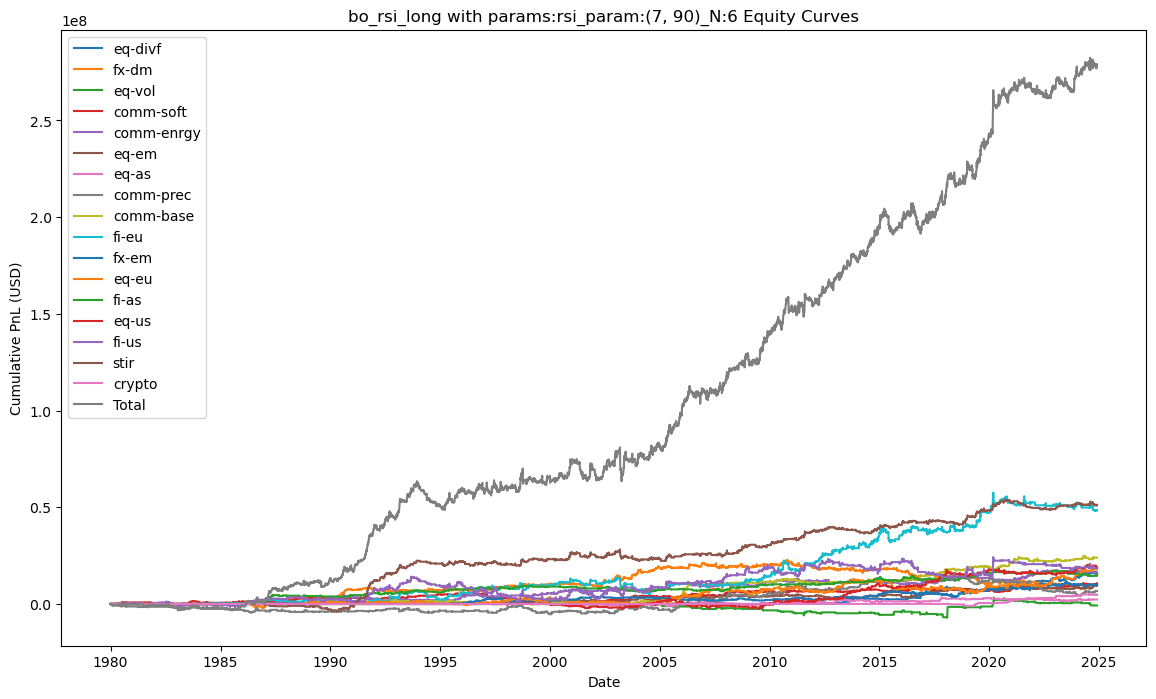

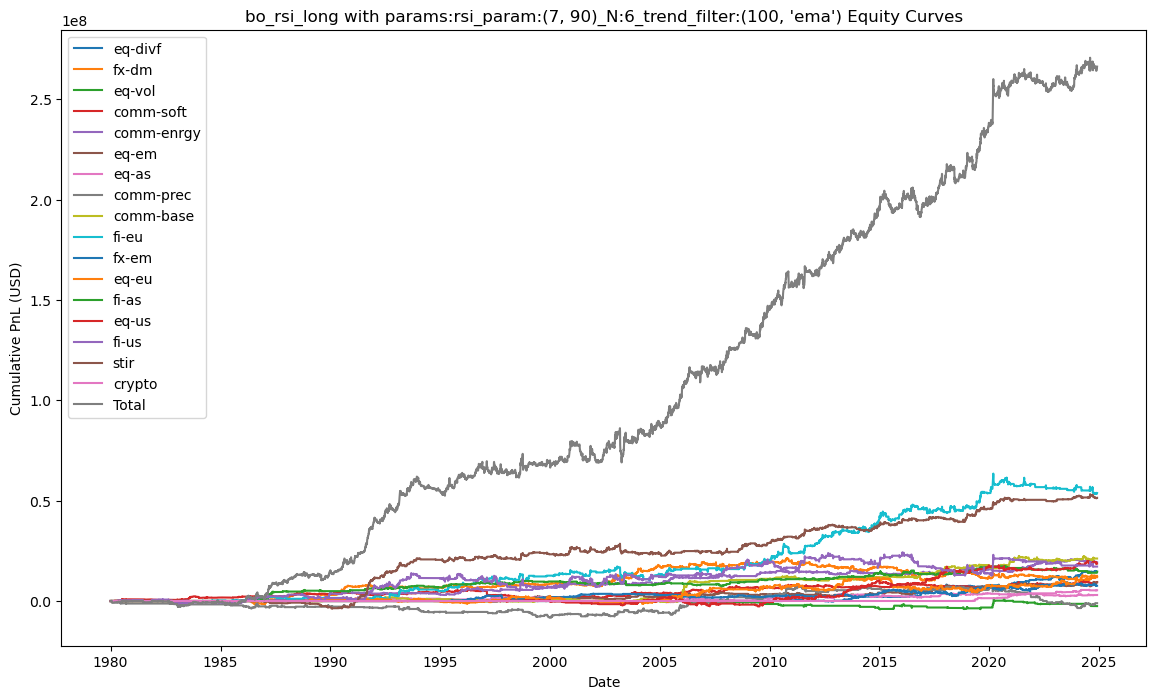

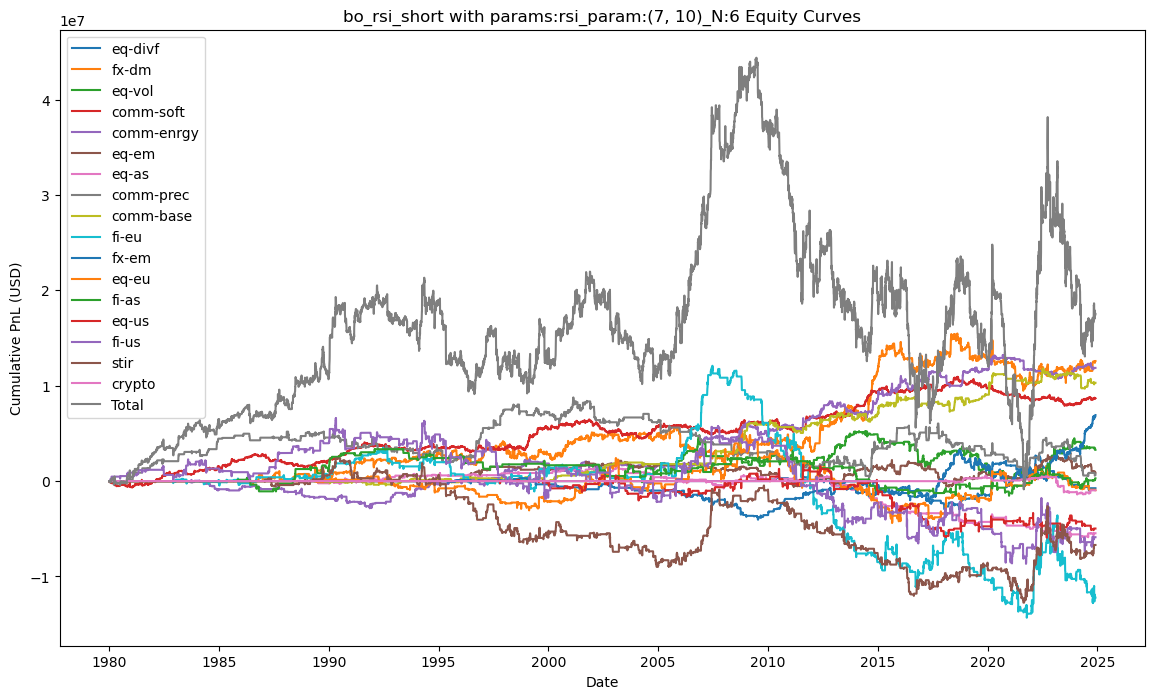

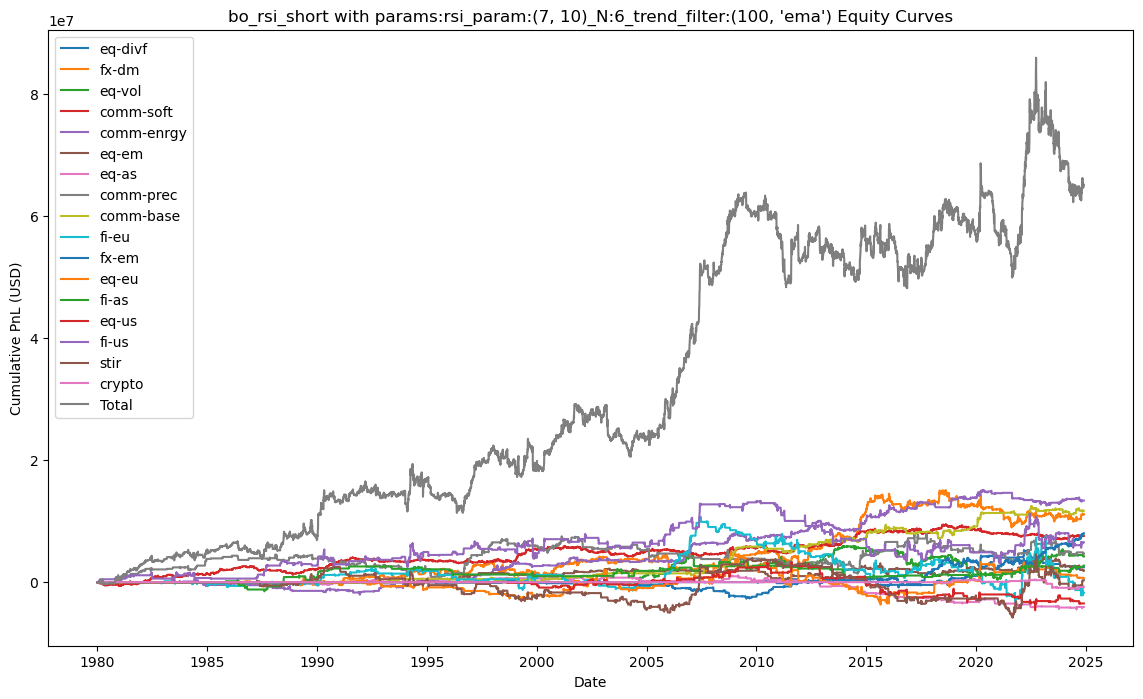

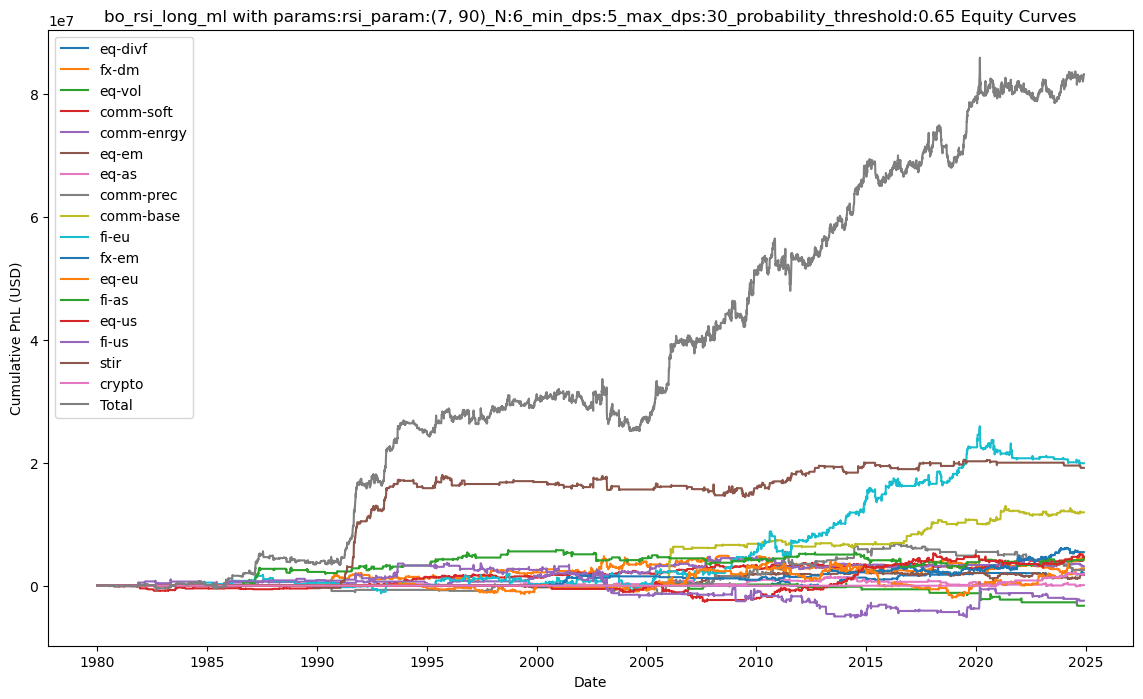

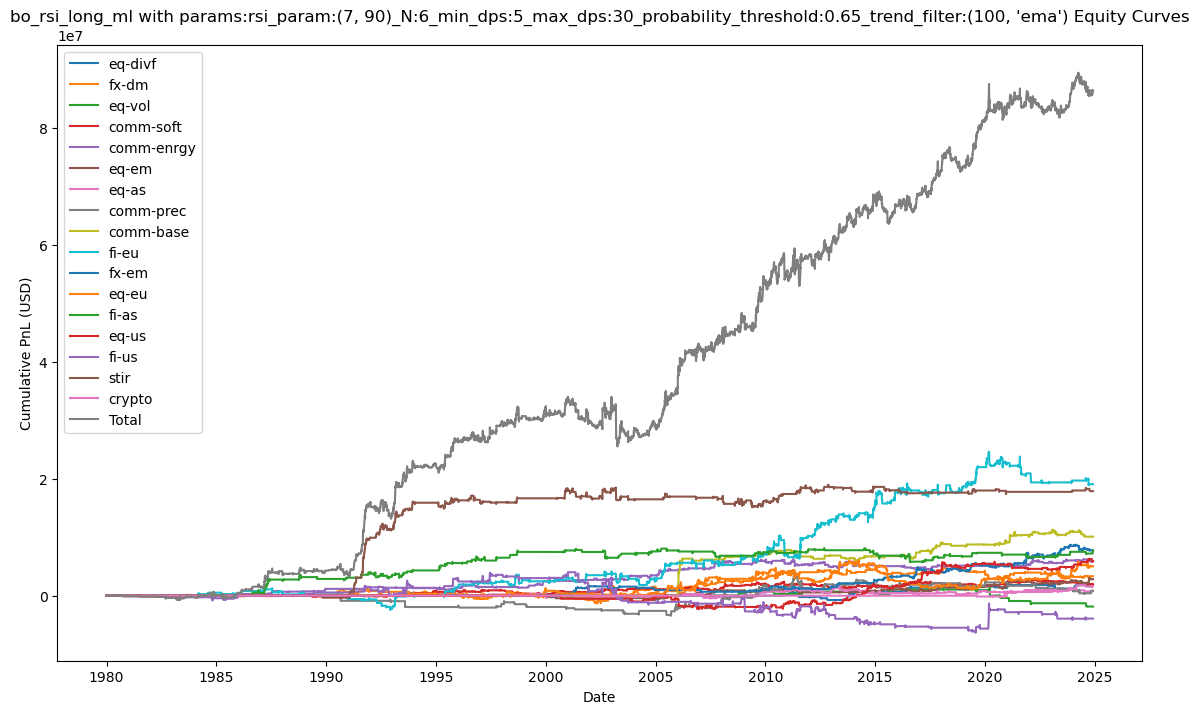

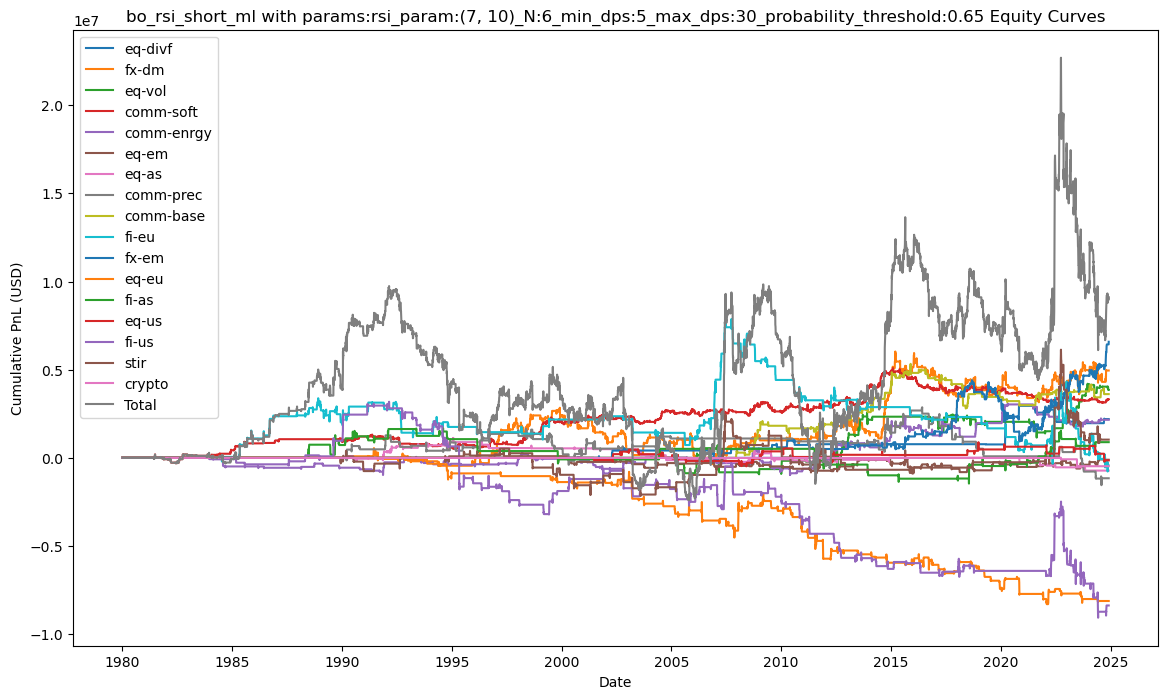

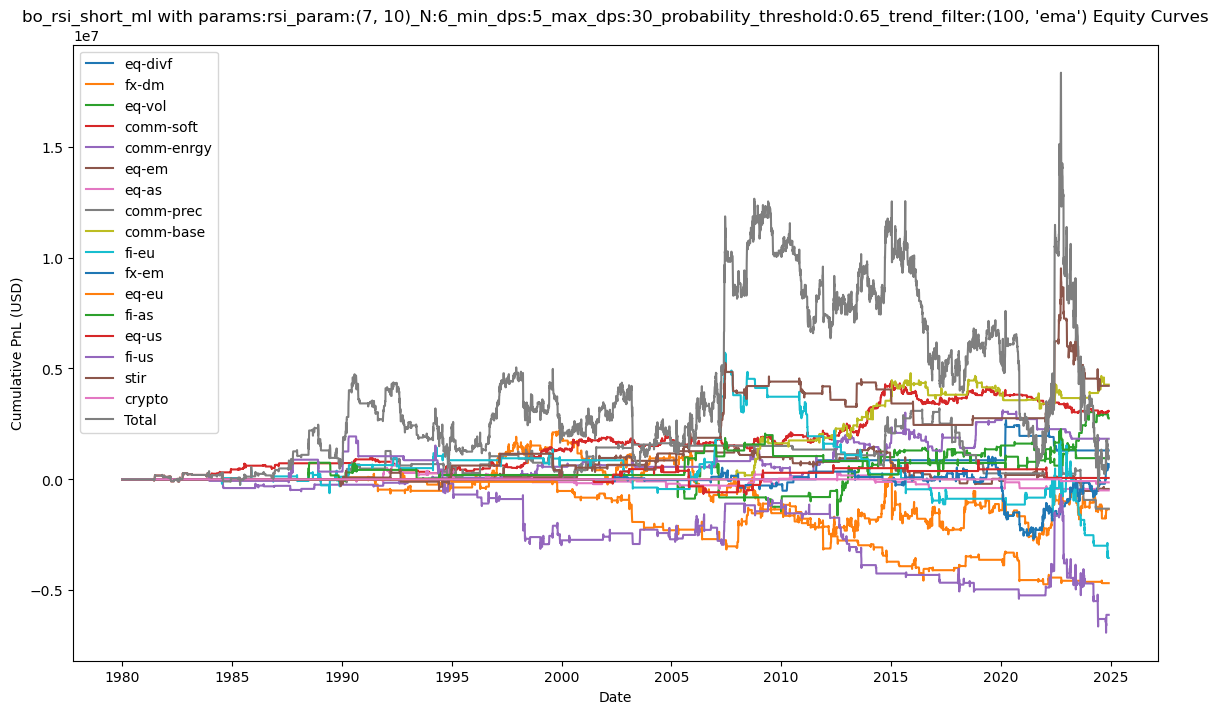

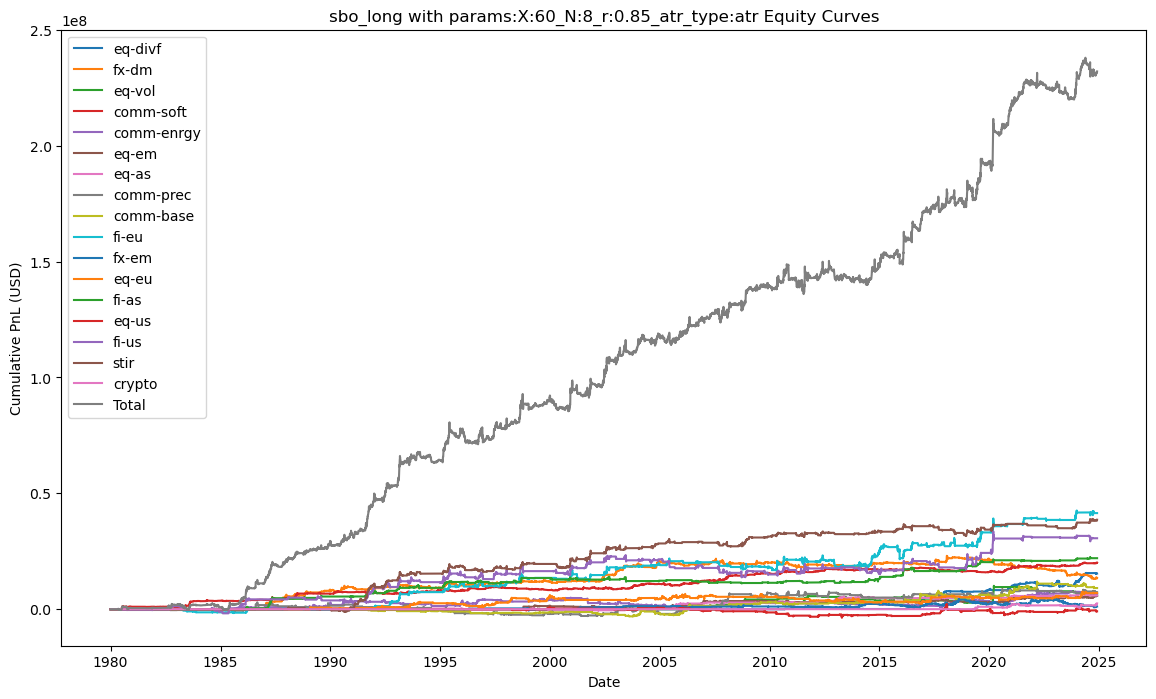

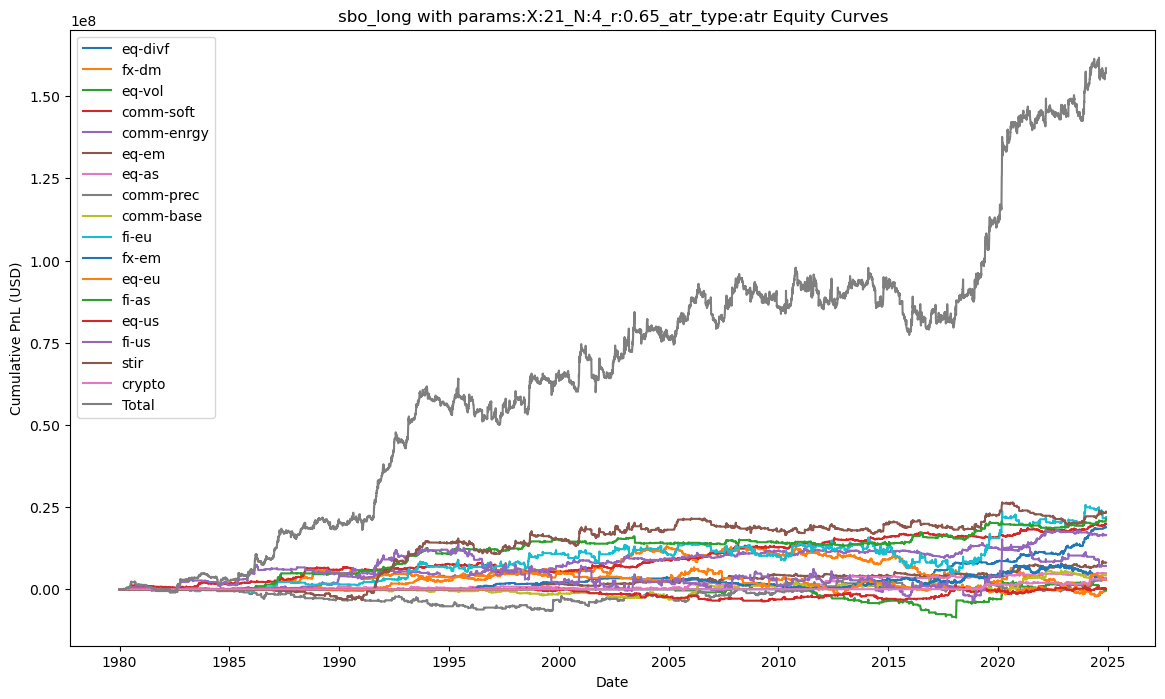

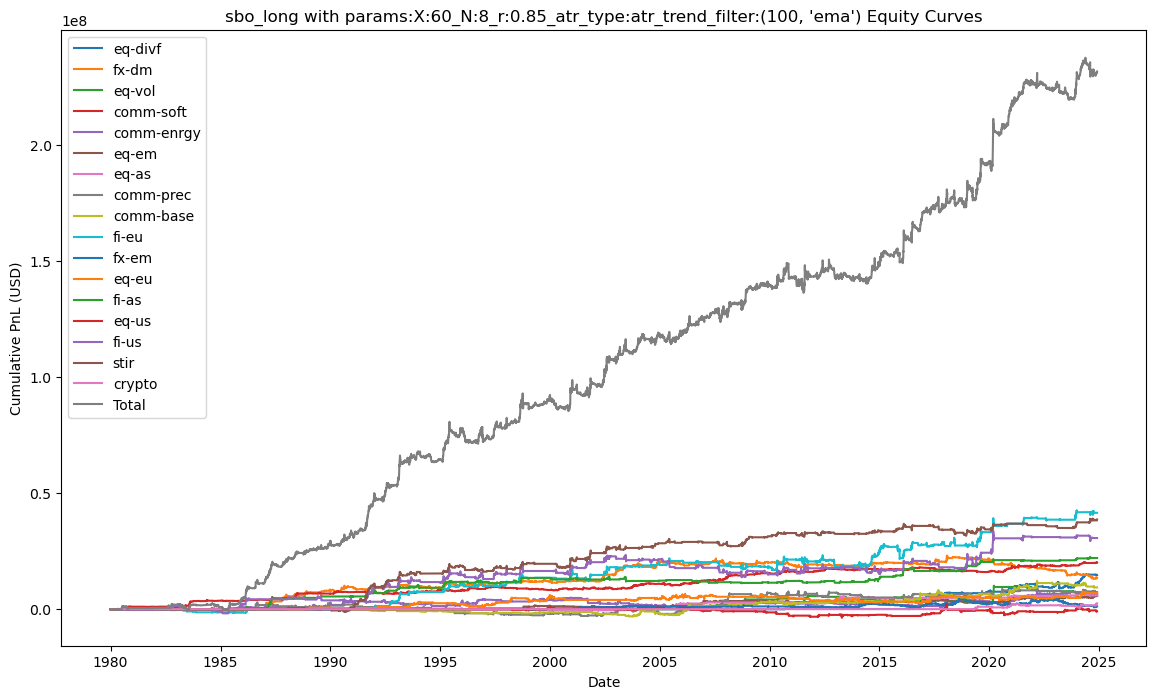

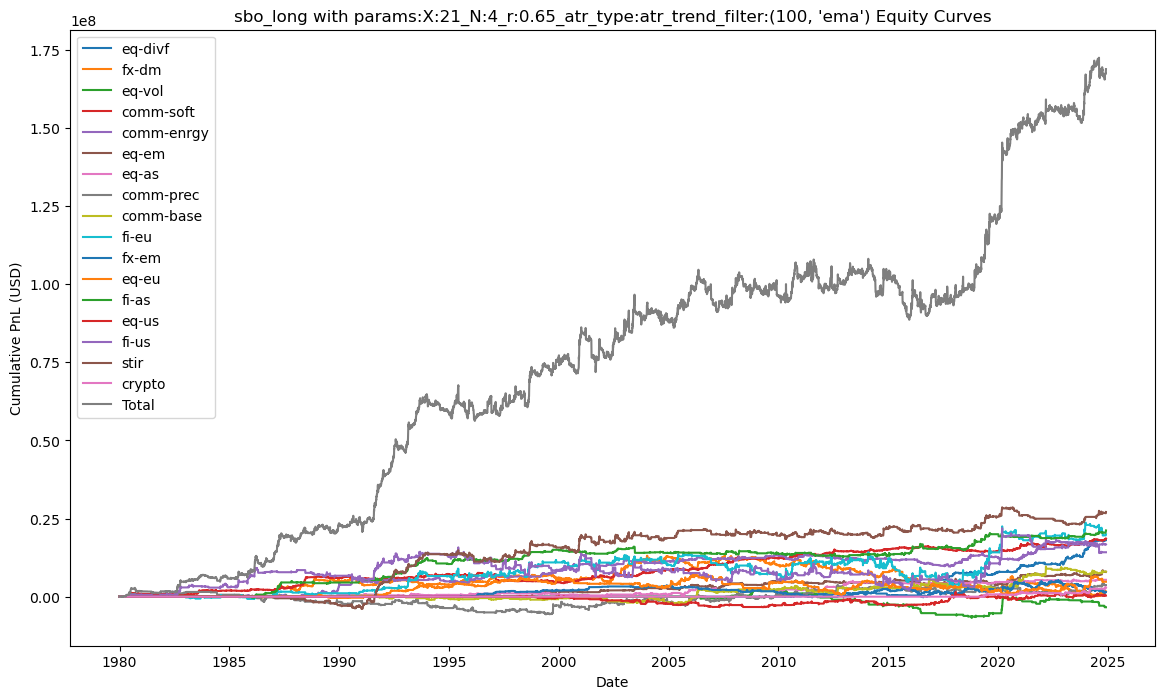

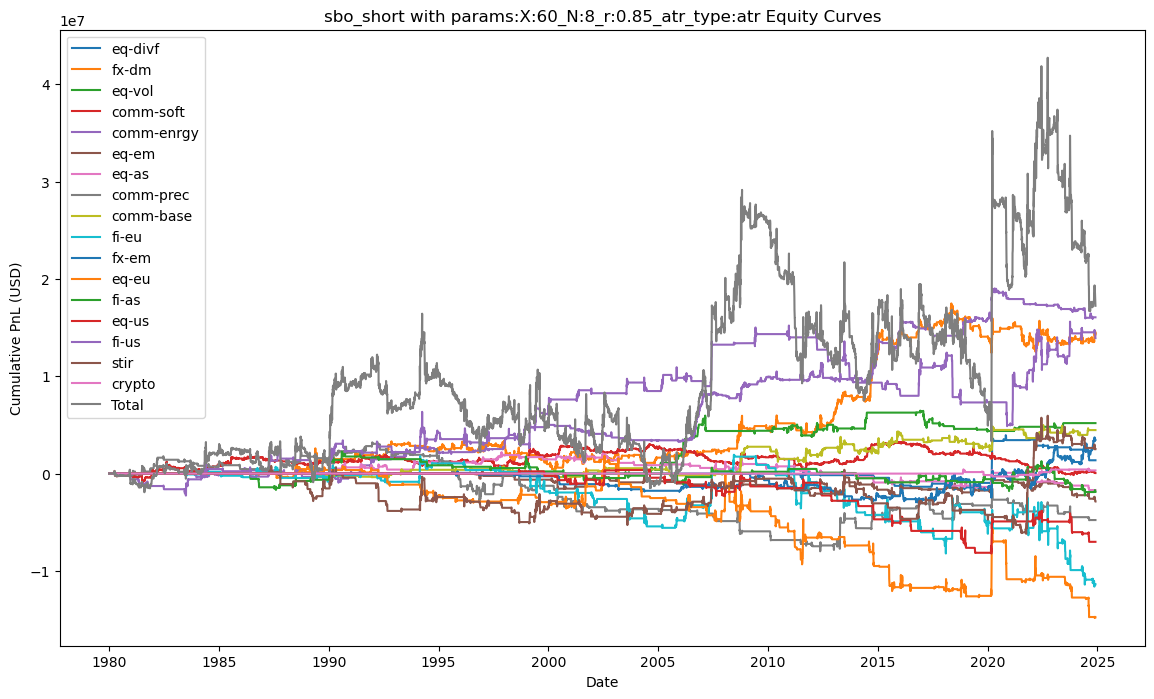

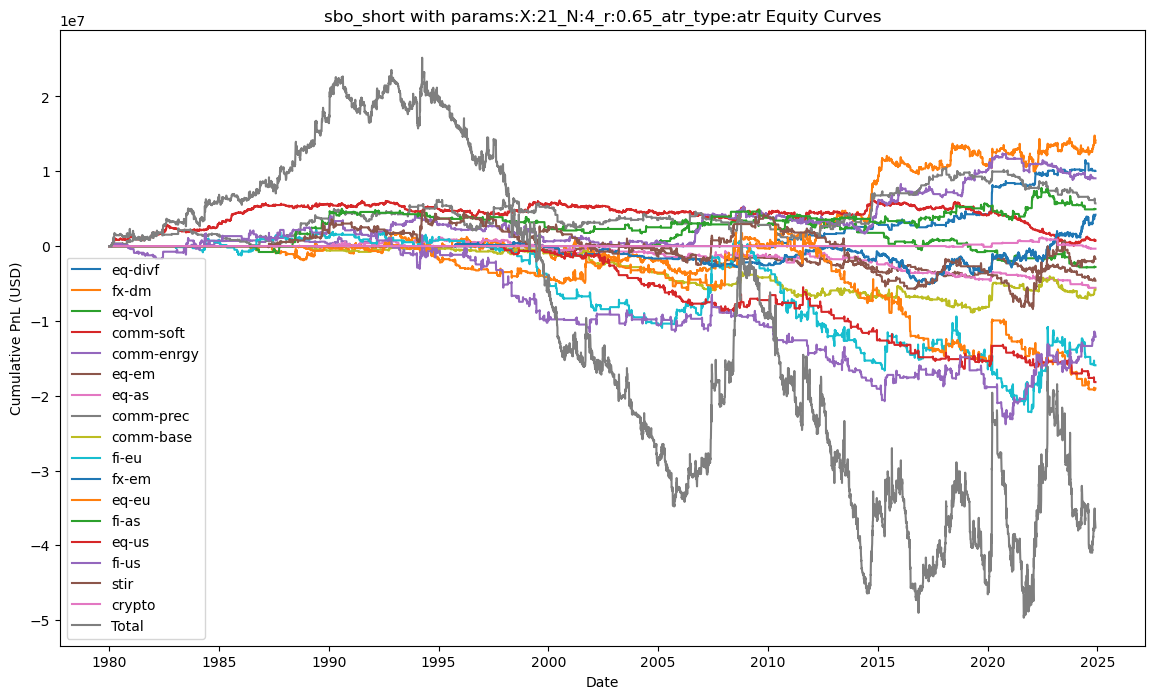

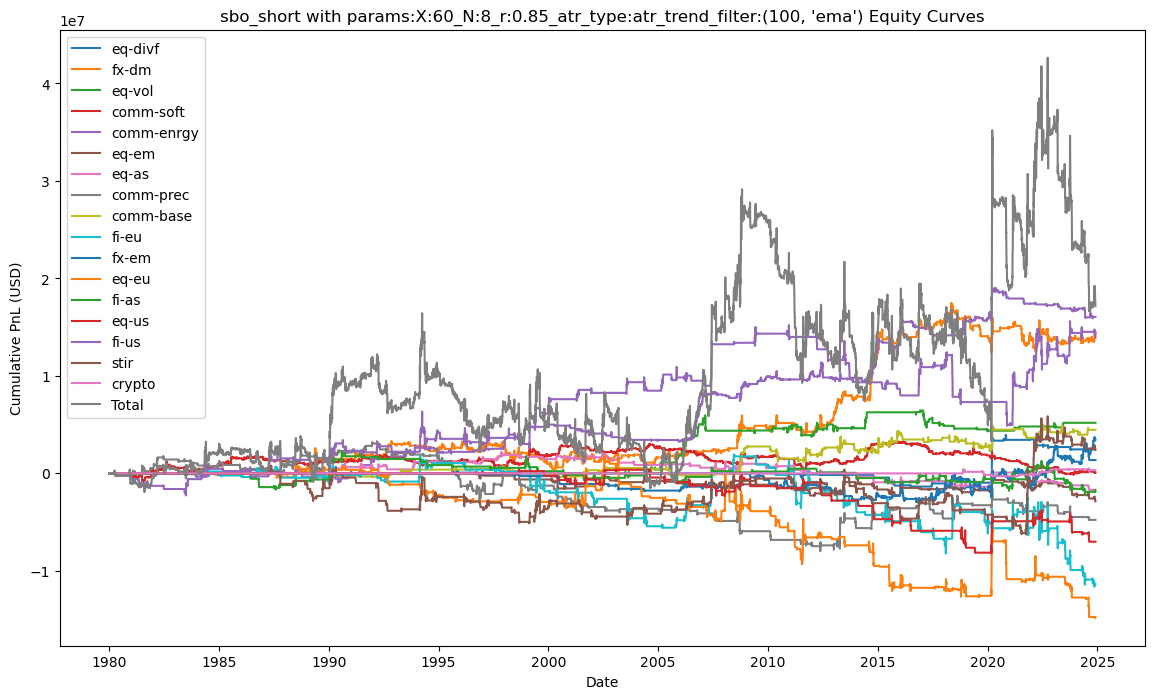

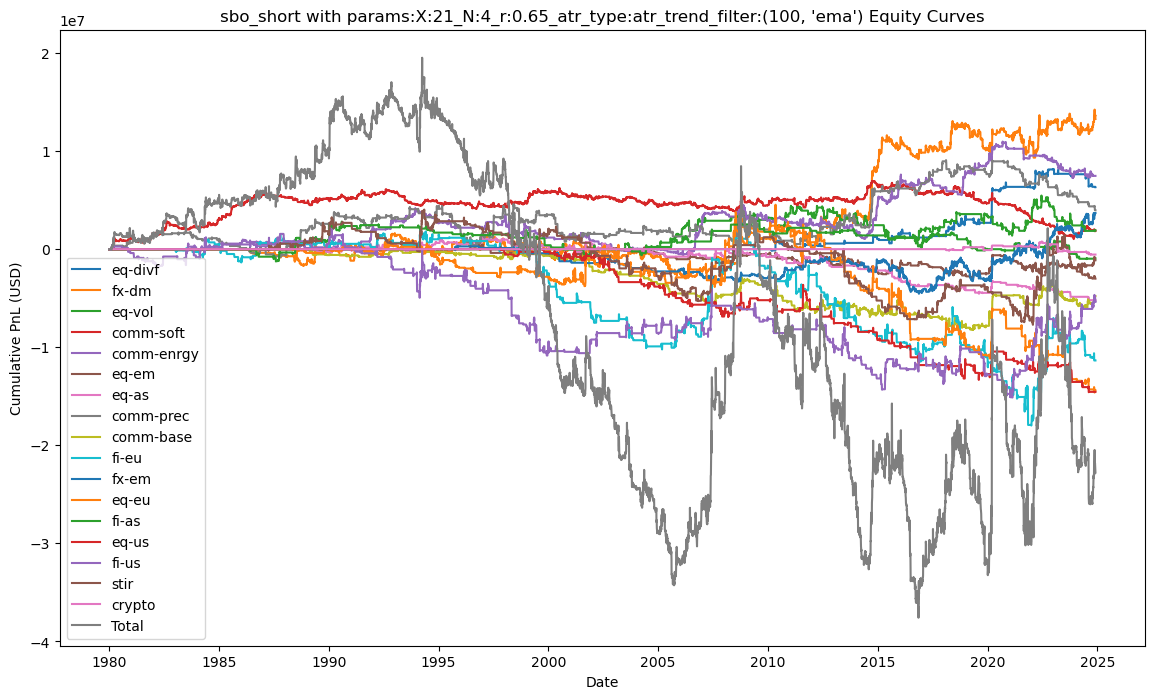

In [6]:
pnl_ts = {}
perf_dfs = {}
pnl_dfs = {}
stats_dfs = {}

start_date=''

for tr in trading_rules_dict.values():
    tmppnldf = tr.plot_equity(byac=True,totalsys=True, start_date=start_date)
    pnl_ts[tr.name_lbl] = tmppnldf
    tmpdf = tr.perf_table(byac=True,metric='sharpe', start_date=start_date)
    perf_dfs[tr.name_lbl] = tmpdf
    tmpdf = tr.perf_table(byac=True, metric='pnl', start_date=start_date)
    pnl_dfs[tr.name_lbl] = tmpdf
    tmpdf = tr.calculate_statistics(start_date=start_date)
    stats_dfs[tr.name_lbl] = tmpdf

In [49]:
stats_dfs = {}

start_date = '01012010'

for tr in trading_rules_dict.values():
    tmpdf = tr.calculate_statistics(start_date=start_date)
    stats_dfs[tr.name_lbl] = tmpdf


# Initialize an empty list to store individual DataFrames
combined_list = []

# Iterate through the dictionary and modify each DataFrame
for key, df in stats_dfs.items():
    # Replace the row index 'Total' with the dictionary key
    df = df.rename(index={'Total': key})
    # Append the modified DataFrame to the list
    combined_list.append(df)

# Concatenate all DataFrames into one
combined_df = pd.concat(combined_list).sort_index()

combined_df

,Total PnL,Average Ann. PnL,Average Ann. Vol,Sharpe Ratio (ann.),Sortino Ratio (ann.),Max drawdown,Average drawdown,Max drawdown Duration,Avg Drawdown Duration,Total Number of Drawdowns,...,Daily Left Tail,Daily Right Tail,Weekly Left Tail,Weekly Right Tail,Monthly Left Tail,Monthly Right Tail,Quarterly Left Tail,Quarterly Right Tail,Yearly Left Tail,Yearly Right Tail
Column,,,,,,,,,,,,,,,,,,,,,
rsi_l,"139,784,078","9,060,079","9,358,912",0.97,1.22,"15,750,446","4,101,977",389,28.5,126,...,2.65,2.25,1.76,1.82,1.08,1.62,1.15,1.44,0.76,1.93
rsi_l_ml,"32,458,260","2,103,776","3,644,201",0.58,0.66,"8,516,409","3,111,901",1234,48.1,77,...,3.26,2.43,2.28,1.78,1.59,1.66,1.08,1.36,0.71,1.57
rsi_l_ml_tf,"33,120,703","2,146,160","3,533,647",0.61,0.69,"6,442,233","2,210,352",990,36.7,100,...,3.33,2.59,2.30,1.86,1.44,1.22,0.96,0.96,0.70,1.18
rsi_l_tf,"121,309,023","7,862,622","8,715,250",0.90,1.11,"14,729,994","4,255,933",622,34.4,106,...,2.60,2.18,1.81,1.77,1.27,1.67,1.09,1.63,0.72,2.31
rsi_s,"-19,916,820","-1,291,237","7,116,910",-0.18,-0.22,"39,818,773","19,928,454",3785,776.0,5,...,3.42,3.44,2.18,2.19,1.16,1.57,0.88,1.57,0.60,1.88
rsi_s_ml,"2,668,463","173,000","3,288,112",0.05,0.06,"16,579,223","5,681,030",1771,141.6,27,...,5.80,4.82,3.25,3.25,1.45,2.81,1.02,3.09,0.75,2.73
rsi_s_ml_tf,"-9,134,134","-592,180","3,203,398",-0.18,-0.18,"18,807,005","6,408,088",1826,275.1,14,...,6.85,5.13,4.30,2.70,1.88,2.88,1.49,3.33,1.31,2.35
rsi_s_tf,"4,812,115","311,977","6,390,433",0.05,0.06,"23,685,409","9,057,749",2555,192.2,20,...,3.65,4.22,2.44,2.62,1.33,2.02,0.87,2.35,0.71,2.10
simple_fast_l,"72,768,290","4,717,677","8,634,508",0.55,0.70,"20,465,574","6,775,302",2202,66.2,57,...,2.73,3.16,1.99,3.20,1.01,2.87,0.96,2.62,0.84,3.41


In [50]:
allsysdf = {}
for tr in trading_rules_dict.values():
    tmp = pnl_ts[tr.name_lbl]
    allsysdf[tr.name_lbl] = tmp['Total']

allsysdf = pd.DataFrame(allsysdf)
allsysdf

,rsi_l,rsi_l_tf,rsi_s,rsi_s_tf,rsi_l_ml,rsi_l_ml_tf,rsi_s_ml,rsi_s_ml_tf,simple_slow_l,simple_fast_l,simple_slow_l_tf,simple_fast_l_tf,simple_slow_s,simple_fast_s,simple_slow_s_tf,simple_fast_s_tf
Date,,,,,,,,,,,,,,,,
1980-01-02,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1980-01-03,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1980-01-04,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1980-01-07,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1980-01-08,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-11-26,"278,124,425","265,501,949","17,421,725","65,071,780","82,586,508","86,006,600","8,961,280","902,290","231,639,797","157,111,728","230,996,005","167,424,243","17,784,116","-37,087,565","17,695,429","-22,263,192"
2024-11-27,"278,278,519","265,664,738","17,421,725","65,071,780","82,731,216","86,069,863","8,961,280","902,290","231,700,133","157,495,839","231,056,341","167,808,353","17,426,643","-37,534,155","17,337,956","-22,709,782"
2024-11-28,"278,673,809","266,011,354","17,410,685","65,060,740","83,113,773","86,455,434","8,980,418","921,429","231,767,197","158,044,289","231,123,406","168,356,804","17,421,834","-37,548,403","17,333,146","-22,724,030"


<Axes: xlabel='Date'>

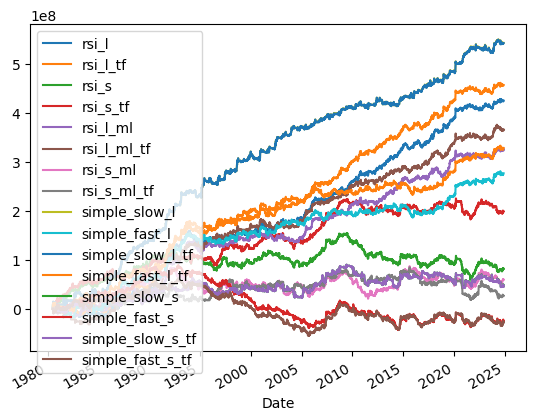

In [51]:
vol_tgt = 10000000
lookback = 126

vol_tgt = 10000000

# Calculate the rolling standard deviation of the last 125 days of returns
rolling_std = allsysdf.diff().rolling(window=lookback).std()

# Calculate the scaling factor to achieve the target annualized volatility
scaling_factor = vol_tgt / (rolling_std * (252 ** 0.5))

# Apply the scaling factor to the returns
scaled_combined_total_df = allsysdf.diff() * scaling_factor
scaled_combined_total_df = scaled_combined_total_df.cumsum()

scaled_combined_total_df.plot()

<Axes: xlabel='Date'>

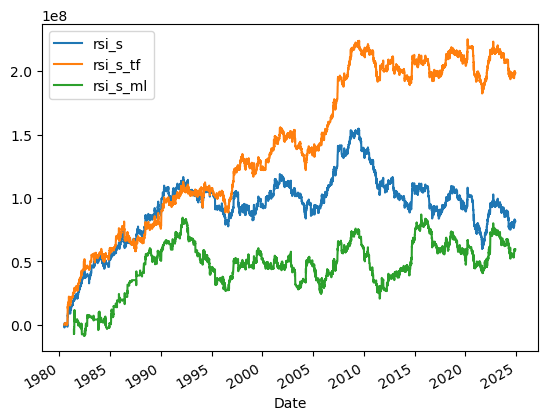

In [52]:
scaled_combined_total_df[['rsi_s', 'rsi_s_tf', 'rsi_s_ml']].plot()

<Axes: xlabel='Date'>

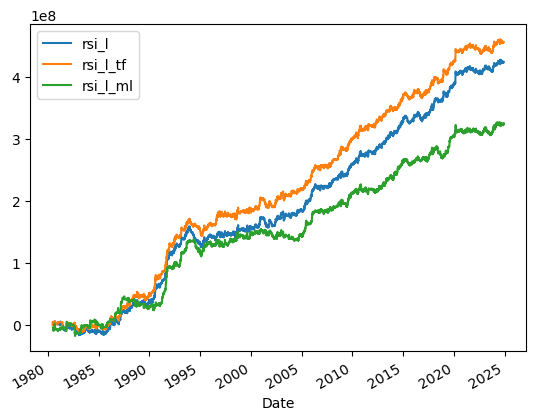

In [53]:
scaled_combined_total_df[['rsi_l', 'rsi_l_tf', 'rsi_l_ml']].plot()

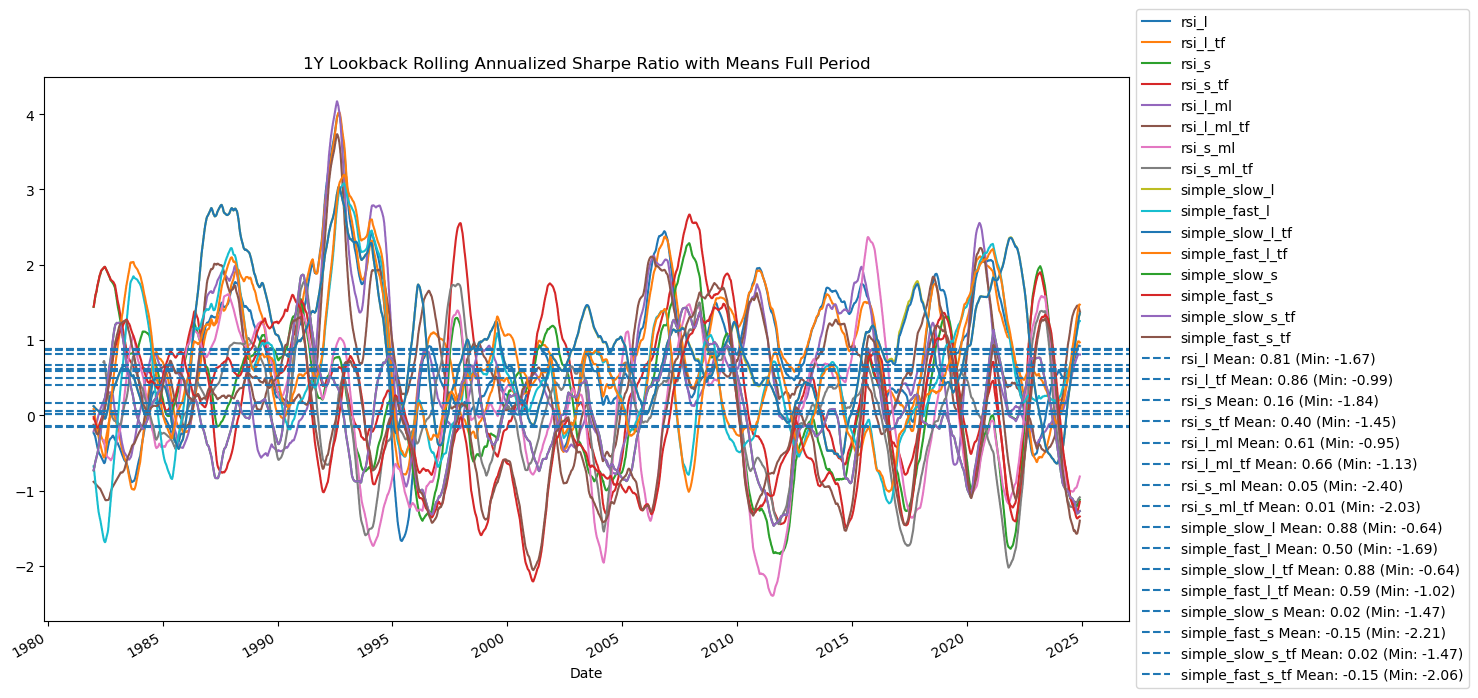

In [54]:

# Calculate the rolling annualized Sharpe ratio for each column in combined_pnl_df
rolling_sharpe = allsysdf.diff().rolling(window=252).apply(lambda x: (x.mean() / x.std()) * (252**0.5))
rolling_sharpe = rolling_sharpe.rolling(window=252).mean()
# Calculate the mean of each series in rolling_sharpe
mean_sharpe = rolling_sharpe.mean()
min_sharpe = rolling_sharpe.min()

# Plot the rolling Sharpe ratios
ax = rolling_sharpe.plot(figsize=(14, 8), title='1Y Lookback Rolling Annualized Sharpe Ratio with Means Full Period')

# Plot the mean of each series as dashed lines
for column in rolling_sharpe.columns:
    ax.axhline(y=mean_sharpe[column], linestyle='--', label=f'{column} Mean: {mean_sharpe[column]:.2f} (Min: {min_sharpe[column]:.2f})')
    # Move the legend outside the chart area


ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

# Show the plot
plt.show()

<Axes: xlabel='Date'>

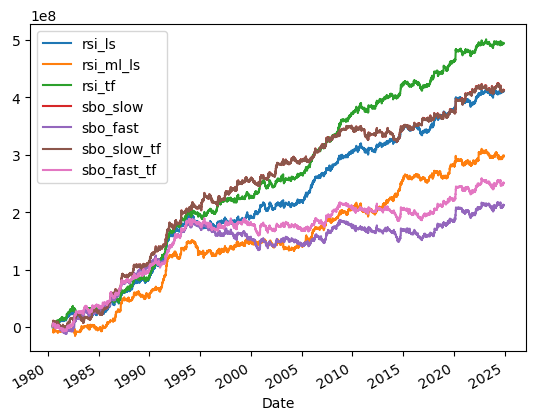

In [55]:
lsdfs = scaled_combined_total_df.copy()
lsdfs['rsi_ls'] = allsysdf['rsi_l'] + allsysdf['rsi_s']
lsdfs['rsi_ml_ls'] = allsysdf['rsi_l_ml'] + allsysdf['rsi_s_ml']
lsdfs['rsi_tf'] = allsysdf['rsi_l_tf'] + allsysdf['rsi_s_tf']
lsdfs['sbo_slow'] = allsysdf['simple_slow_l'] + allsysdf['simple_slow_s']
lsdfs['sbo_fast'] = allsysdf['simple_fast_l'] + allsysdf['simple_fast_s']
lsdfs['sbo_slow_tf'] = allsysdf['simple_slow_l_tf'] + allsysdf['simple_slow_s_tf']
lsdfs['sbo_fast_tf'] = allsysdf['simple_fast_l_tf'] + allsysdf['simple_fast_s_tf']
lsdfs.drop(allsysdf.columns.to_list(), axis=1, inplace=True)
lsdfs

vol_tgt = 10000000
lookback = 126

vol_tgt = 10000000

# Calculate the rolling standard deviation of the last 125 days of returns
rolling_std = lsdfs.diff().rolling(window=lookback).std()

# Calculate the scaling factor to achieve the target annualized volatility
scaling_factor = vol_tgt / (rolling_std * (252 ** 0.5))

# Apply the scaling factor to the returns
scaled_combined_total_df = lsdfs.diff() * scaling_factor
scaled_combined_total_df = scaled_combined_total_df.cumsum()

scaled_combined_total_df.plot()

<Axes: xlabel='Date'>

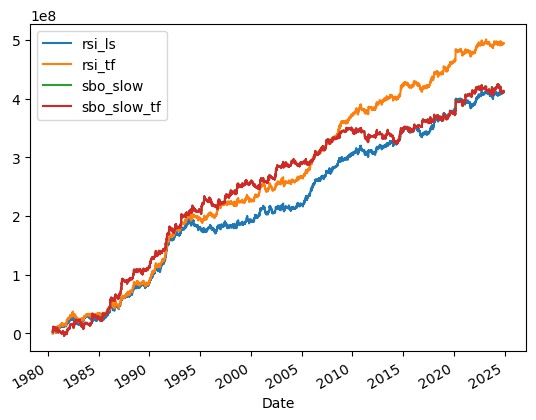

In [13]:
scaled_combined_total_df[['rsi_ls','rsi_tf', 'sbo_slow', 'sbo_slow_tf']].plot()

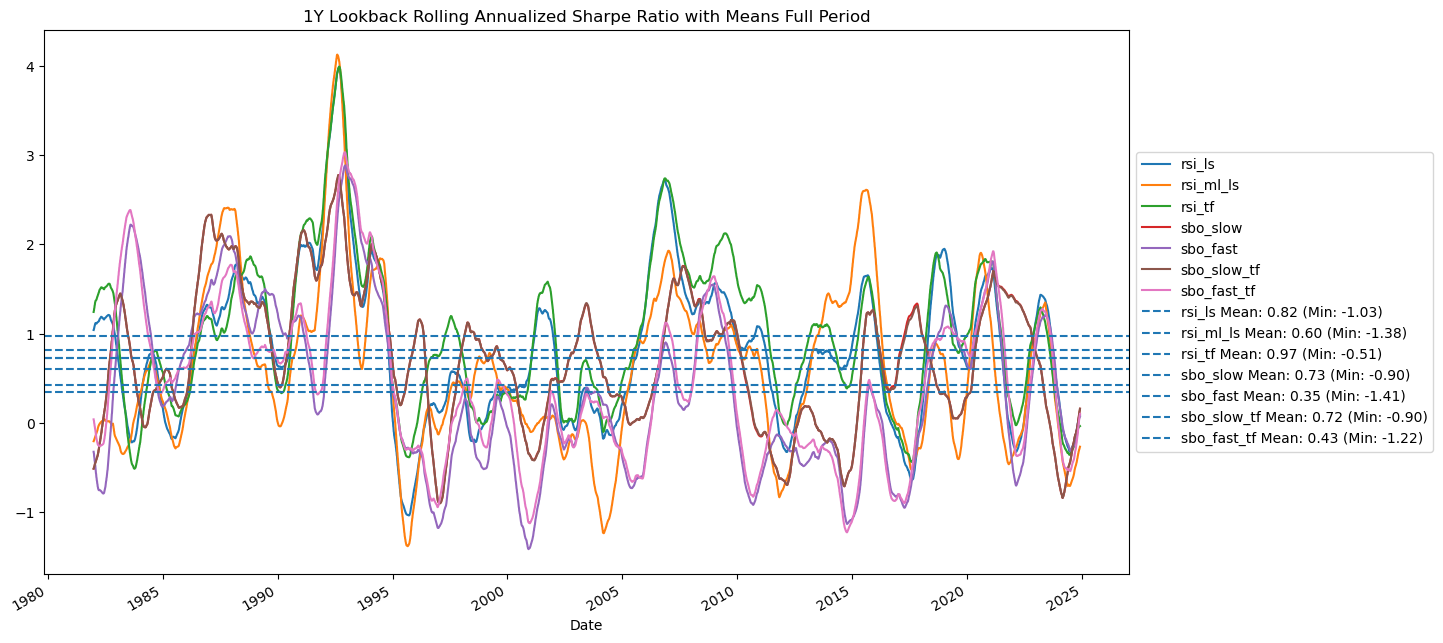

In [14]:

# Calculate the rolling annualized Sharpe ratio for each column in combined_pnl_df
rolling_sharpe = lsdfs.diff().rolling(window=252).apply(lambda x: (x.mean() / x.std()) * (252**0.5))
rolling_sharpe = rolling_sharpe.rolling(window=252).mean()
# Calculate the mean of each series in rolling_sharpe
mean_sharpe = rolling_sharpe.mean()
min_sharpe = rolling_sharpe.min()

# Plot the rolling Sharpe ratios
ax = rolling_sharpe.plot(figsize=(14, 8), title='1Y Lookback Rolling Annualized Sharpe Ratio with Means Full Period')

# Plot the mean of each series as dashed lines
for column in rolling_sharpe.columns:
    ax.axhline(y=mean_sharpe[column], linestyle='--', label=f'{column} Mean: {mean_sharpe[column]:.2f} (Min: {min_sharpe[column]:.2f})')
    # Move the legend outside the chart area


ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

# Show the plot
plt.show()

In [15]:
ml_short = trading_rules_dict['rsi_s_ml']
ml_long = trading_rules_dict['rsi_l_ml']

In [16]:
display(ml_short.strat_monthly_pnl())
display(ml_long.strat_monthly_pnl())

,1,2,3,4,5,6,7,8,9,10,11,12,Annual_PnL,Sharpe_Ratio,Annual_Vol,Hit_Rate,Profit_Factor,Worst_Drawdown
Year,,,,,,,,,,,,,,,,,,
1980,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,0.00,0.00,NaN,0.00
1981,0.00,0.00,0.00,0.00,0.00,"147,135","-145,790",0.00,"44,110","-65,970","6,545","-57,675","-71,645",-0.34,"211,641",0.49,0.87,"-287,037"
1982,"-17,525","9,025","-192,453",0.00,0.00,"-25,440","165,902","58,128","81,658","186,590",0.00,"-46,575","219,310",0.70,"307,530",0.48,1.26,"-251,348"
1983,0.00,0.00,"-9,520",0.00,"-20,200",0.00,0.00,0.00,0.00,"-14,886","17,573","-70,250","-97,283",-0.36,"265,495",0.39,0.82,"-239,875"
1984,"51,775","-73,420",0.00,"21,930",0.00,"40,850","55,407","-393,790","-17,860",0.00,"34,338","162,275","-118,496",-0.25,"468,075",0.48,0.90,"-466,350"
1985,"-11,760","373,789","-341,688","28,260","684,991",0.00,"56,606","-10,100","372,239",0.00,"11,217","-22,906","1,140,650",1.03,"1,073,657",0.56,1.47,"-723,837"
1986,0.00,0.00,"-10,460",0.00,"25,675","107,999",0.00,0.00,"935,670",0.00,"148,987","143,928","1,351,799",1.58,"829,344",0.59,2.41,"-244,418"
1987,0.00,"70,975",0.00,0.00,0.00,0.00,"31,094","139,281",0.00,0.00,0.00,"48,271","289,622",0.59,"479,226",0.56,1.48,"-222,938"
1988,0.00,"49,434",0.00,"124,345","282,130","421,021","677,735",0.00,"70,374","34,175","411,738","-14,753","2,056,200",1.57,"1,273,357",0.59,2.00,"-473,731"


,1,2,3,4,5,6,7,8,9,10,11,12,Annual_PnL,Sharpe_Ratio,Annual_Vol,Hit_Rate,Profit_Factor,Worst_Drawdown
Year,,,,,,,,,,,,,,,,,,
1980,0.00,0.00,0.00,0.00,0.00,0.00,"-30,282","54,110","-88,842","-34,000",0.00,"-12,488","-111,502",-0.72,"156,463",0.39,0.71,"-233,990"
1981,"22,800",0.00,"18,756",0.00,0.00,0.00,"-12,642",0.00,0.00,"-63,996","500,812","-285,165","180,566",0.41,"441,209",0.48,1.25,"-315,165"
1982,0.00,"-90,781","273,500","-140,512",0.00,0.00,"-236,375","-279,750","-13,844",0.00,"15,962",0.00,"-471,800",-0.77,"598,634",0.42,0.72,"-1,012,825"
1983,"34,788","-32,338","99,325","5,438","263,969",0.00,"268,132","140,550",0.00,0.00,"-69,988","-46,050","663,826",0.70,"932,379",0.55,1.48,"-563,531"
1984,"-61,500","182,421","62,674",0.00,"40,512",0.00,0.00,"195,420","-308,750",0.00,"-348,679","100,406","-137,497",-0.17,"779,512",0.44,0.94,"-732,775"
1985,"-26,787",0.00,"-111,537","-388,312",0.00,"144,250",0.00,0.00,"194,146","617,134","322,074","311,625","1,062,592",0.68,"1,515,980",0.51,1.30,"-932,844"
1986,0.00,"432,808",0.00,0.00,0.00,"-48,450","-65,055","521,503","47,188","-28,000","282,509","-363,790","778,713",1.15,"656,595",0.51,1.65,"-512,195"
1987,"-100,988","268,854","1,802,950","331,118","952,244","-145,997","-422,233",0.00,0.00,"-179,031","384,677","-144,240","2,747,354",1.83,"1,456,444",0.56,1.82,"-1,164,313"
1988,"-299,668",0.00,"-8,631","82,214",0.00,"60,306",0.00,"-659,844",0.00,"790,790","-407,537","-195,494","-637,863",-0.67,"928,150",0.46,0.78,"-818,676"


In [17]:
perf = ml_short.perf_table(byassets=True, metric='sharpe', filter_assets=asset_classes['fx-dm'])

In [18]:
perf.head(30)

Period                 2024  2023  2022  2021  2020  2019  2018  2017  2016  \
AssetClass Asset                                                              
Unknown    Total      -0.02  0.60  0.32  0.31 -0.13 -0.38  0.54 -1.19 -0.52   
fx-dm      AD1 Curncy  1.09  0.01 -0.12   NaN -0.79 -0.06  0.71 -0.28 -1.08   
           BP1 Curncy  0.17  1.09  0.22   NaN  0.62 -1.47 -0.43  0.21  0.65   
           CD1 Curncy -1.20  0.49 -0.66 -1.01  0.64  0.46   NaN -1.13 -0.19   
           DX1 Curncy -0.84   NaN -0.36   NaN -1.33   NaN   NaN   NaN   NaN   
           EC1 Curncy   NaN   NaN  0.52  0.75   NaN -1.53  0.68 -0.85 -0.19   
           JY1 Curncy  0.95  0.06  1.36  0.33   NaN   NaN   NaN   NaN  0.19   
           NO1 Curncy -0.51  0.17 -0.49 -0.41  1.08   NaN -1.72 -1.28 -0.44   
           NV1 Curncy -0.05  0.64   NaN  0.72 -1.56  1.53   NaN -0.08 -0.53   
           SE1 Curncy  1.34 -0.58 -1.50  0.90  0.20 -1.26  0.92 -0.40 -0.46   
           SF1 Curncy -1.64  0.38  0.91 -1.28  0.18  1.06  0.81 -0.21 -0.41   

Period                 2015  ...  1998  1997  1996  1995  1994  1993  1992  \
AssetClass Asset             ...                                             
Unknown    Total       1.00  ...  0.87  1.58  0.69  0.89 -1.37 -0.61  0.44   
fx-dm      AD1 Curncy  0.72  ...   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
           BP1 Curncy -0.50  ...  1.86  0.17 -0.29   NaN -1.37 -0.13  0.24   
           CD1 Curncy  1.42  ...  1.11  1.17   NaN  0.89   NaN   NaN   NaN   
           DX1 Curncy   NaN  ...  0.65   NaN  0.85   NaN   NaN   NaN   NaN   
           EC1 Curncy  0.77  ...   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
           JY1 Curncy   NaN  ... -0.88  0.69 -0.58   NaN   NaN   NaN   NaN   
           NO1 Curncy -0.37  ...   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
           NV1 Curncy -0.32  ...   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
           SE1 Curncy  0.28  ...   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
           SF1 Curncy  1.00  ...  0.07  0.90  1.70   NaN   NaN -0.76  0.38   

Period                 1991  1990   Avg  
AssetClass Asset                         
Unknown    Total      -0.23  0.42  0.09  
fx-dm      AD1 Curncy -0.04   NaN  0.11  
           BP1 Curncy  0.82   NaN -0.00  
           CD1 Curncy   NaN   NaN  0.03  
           DX1 Curncy   NaN   NaN  0.31  
           EC1 Curncy   NaN   NaN -0.04  
           JY1 Curncy -0.46  0.42  0.03  
           NO1 Curncy   NaN   NaN -0.29  
           NV1 Curncy   NaN   NaN -0.14  
           SE1 Curncy   NaN   NaN -0.04  
           SF1 Curncy -0.45   NaN  0.05  

[11 rows x 36 columns]

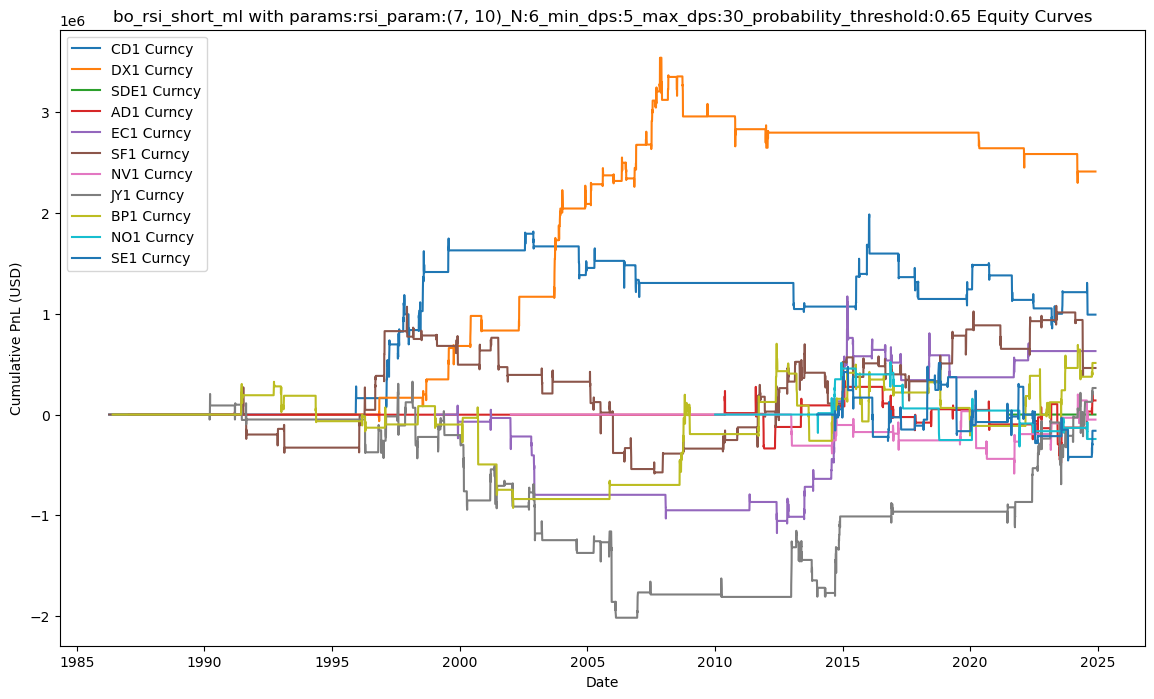

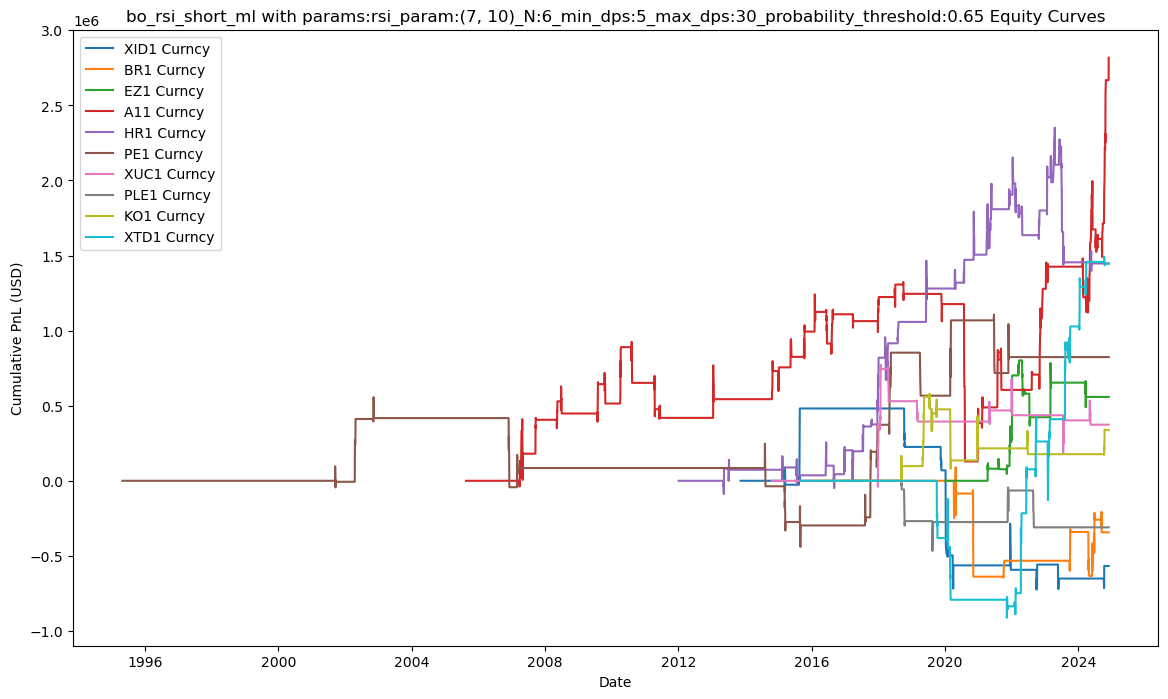

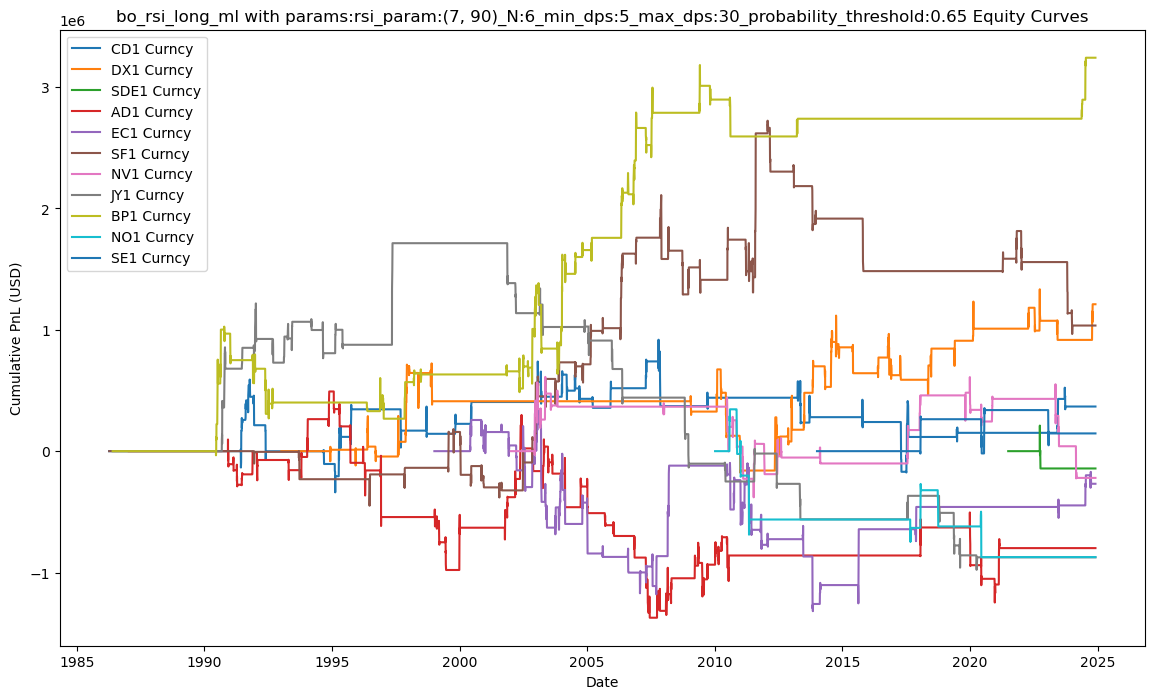

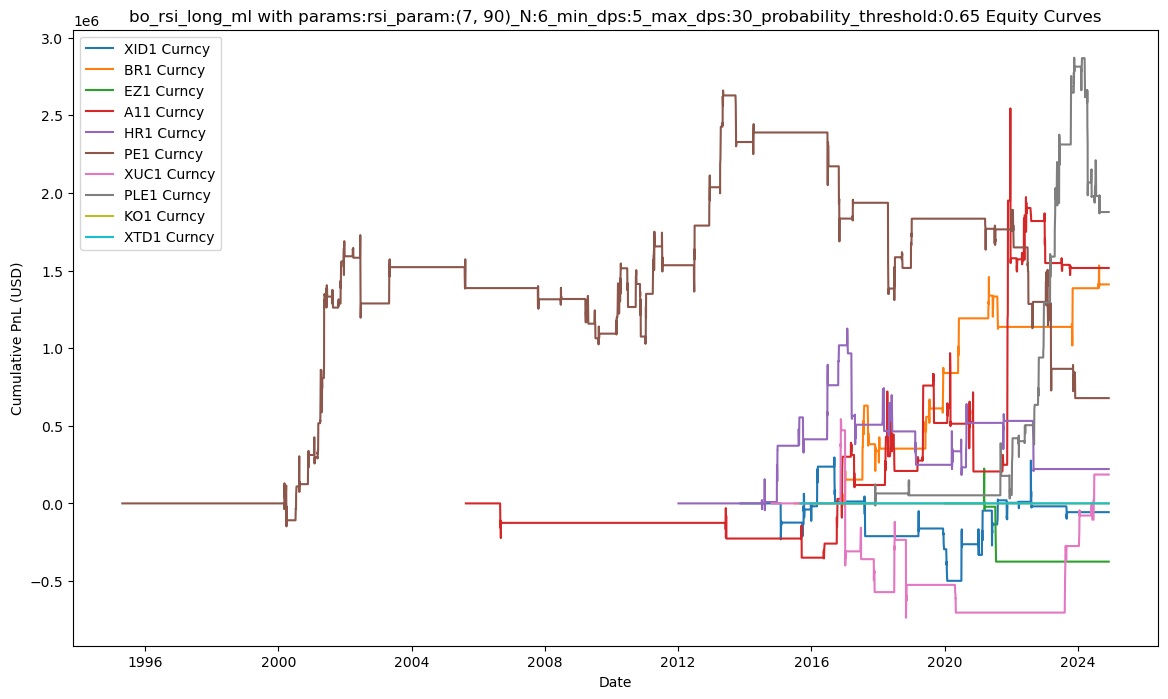

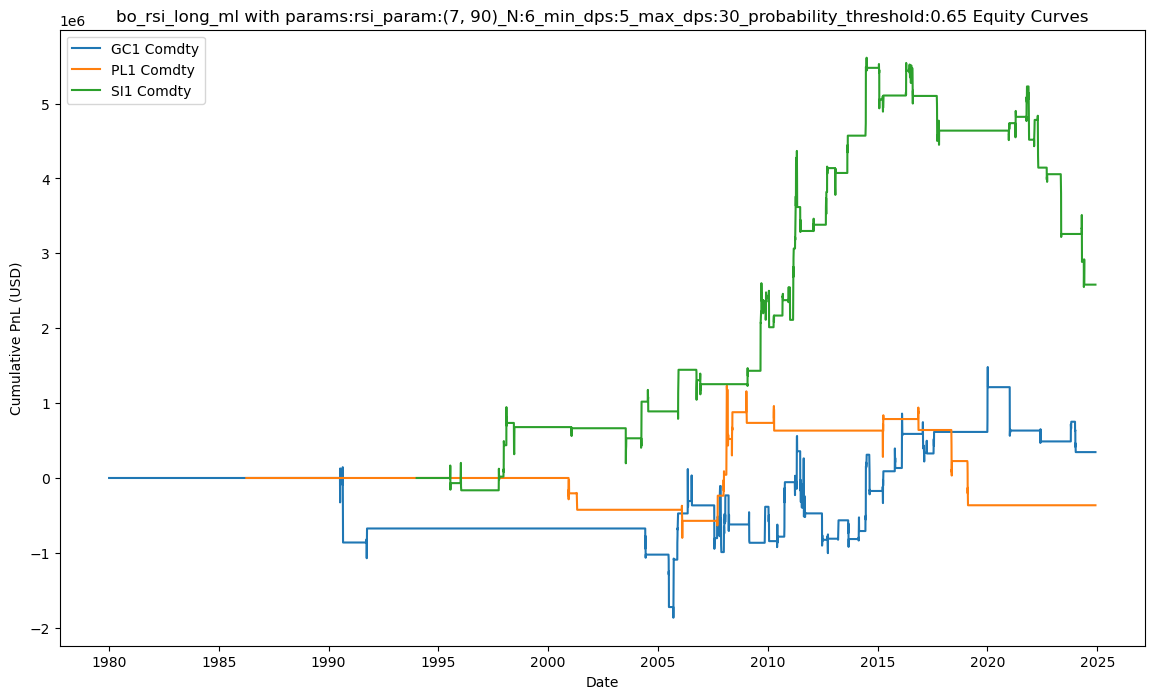

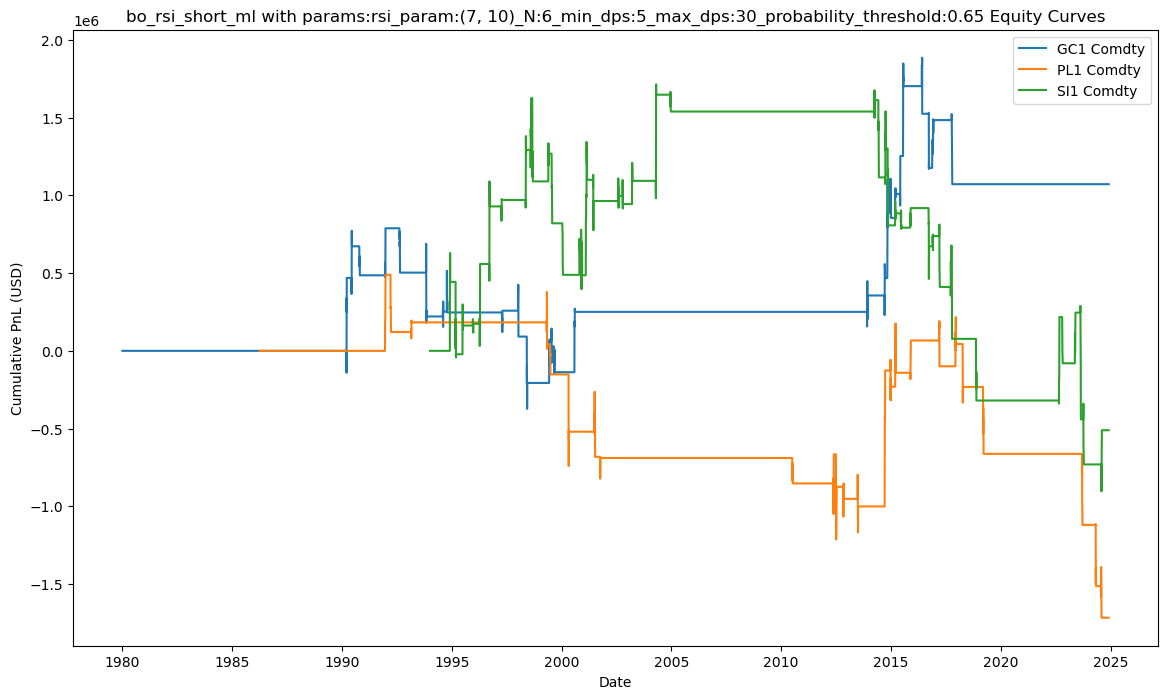

,GC1 Comdty,PL1 Comdty,SI1 Comdty,Total
Date,,,,
1980-01-02,NaN,NaN,NaN,0.00
1980-01-03,0.00,NaN,NaN,0.00
1980-01-04,0.00,NaN,NaN,0.00
1980-01-07,0.00,NaN,NaN,0.00
1980-01-08,0.00,NaN,NaN,0.00
...,...,...,...,...
2024-11-22,"1,071,700","-1,716,370","-510,560","-1,155,230"
2024-11-25,"1,071,700","-1,716,370","-510,560","-1,155,230"
2024-11-26,"1,071,700","-1,716,370","-510,560","-1,155,230"


In [19]:
ml_short.plot_equity(byassets=True, totalsys=False,filter_assets=asset_classes['fx-dm'])
ml_short.plot_equity(byassets=True, totalsys=False,filter_assets=asset_classes['fx-em'])
ml_long.plot_equity(byassets=True, totalsys=False,filter_assets=asset_classes['fx-dm'])
ml_long.plot_equity(byassets=True, totalsys=False,filter_assets=asset_classes['fx-em'])
ml_long.plot_equity(byassets=True, totalsys=False,filter_assets=asset_classes['comm-prec'])
ml_short.plot_equity(byassets=True, totalsys=False,filter_assets=asset_classes['comm-prec'])

In [20]:
tcker = 'BTS1 Comdty'
market_data.get_ticker_data(tcker).to_pandas().to_clipboard()

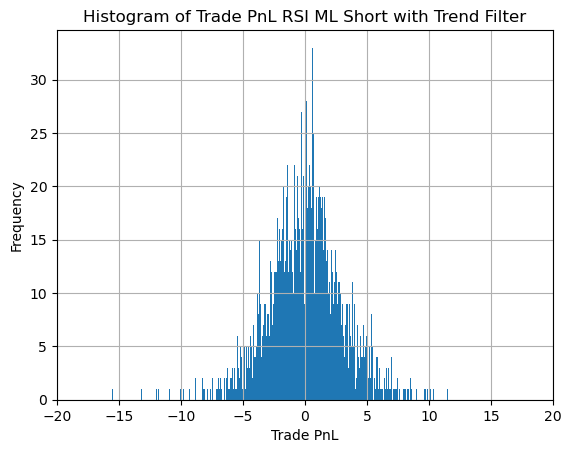

In [21]:
tradeslist_ml_s = ml_short._full_tradeslist()
tradeslist_ml_s
tradeslist_ml_s['Std_PnL'].hist(bins=1000)
plt.xlabel('Trade PnL')
plt.ylabel('Frequency')
plt.xlim(-20, 20)
plt.title('Histogram of Trade PnL RSI ML Short with Trend Filter')
plt.show()

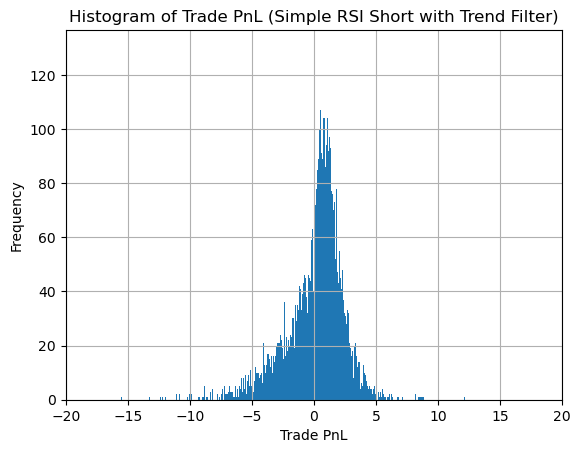

In [22]:
tradeslist_s_tf = trading_rules_dict['rsi_s_tf']._full_tradeslist()
tradeslist_s_tf
tradeslist_s_tf['Std_PnL'].hist(bins=1000)
plt.xlabel('Trade PnL')
plt.ylabel('Frequency')
plt.xlim(-20, 20)
plt.title('Histogram of Trade PnL (Simple RSI Short with Trend Filter)')
plt.show()

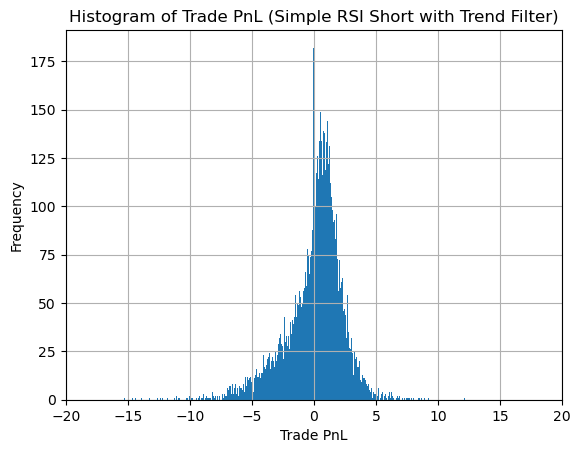

In [23]:
tradeslist_s = trading_rules_dict['rsi_s']._full_tradeslist()
tradeslist_s
tradeslist_s['Std_PnL'].hist(bins=1000)
plt.xlabel('Trade PnL')
plt.ylabel('Frequency')
plt.xlim(-20, 20)
plt.title('Histogram of Trade PnL (Simple RSI Short with Trend Filter)')
plt.show()

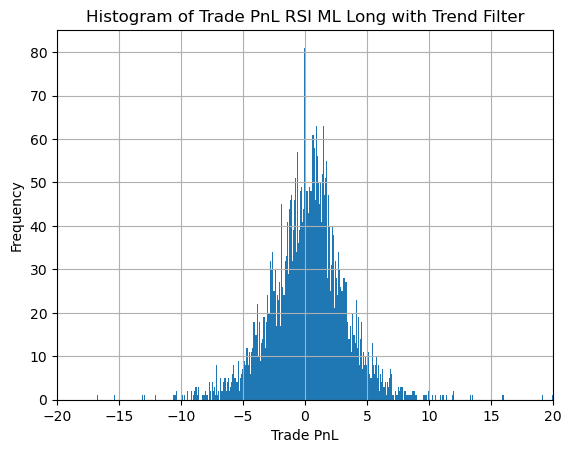

In [24]:
tradeslist_ml_l = ml_long._full_tradeslist()
tradeslist_ml_l
tradeslist_ml_l['Std_PnL'].hist(bins=1000)
plt.xlabel('Trade PnL')
plt.ylabel('Frequency')
plt.xlim(-20, 20)
plt.title('Histogram of Trade PnL RSI ML Long with Trend Filter')
plt.show()

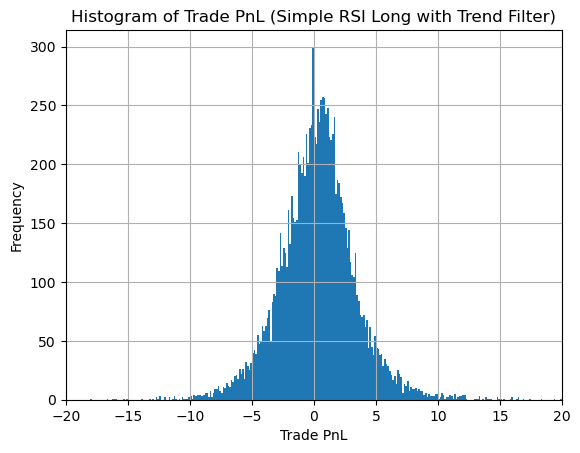

In [25]:
tradeslist_l_tf = trading_rules_dict['rsi_l_tf']._full_tradeslist()
tradeslist_l_tf
tradeslist_l_tf['Std_PnL'].hist(bins=1000)
plt.xlabel('Trade PnL')
plt.ylabel('Frequency')
plt.xlim(-20, 20)
plt.title('Histogram of Trade PnL (Simple RSI Long with Trend Filter)')
plt.show()

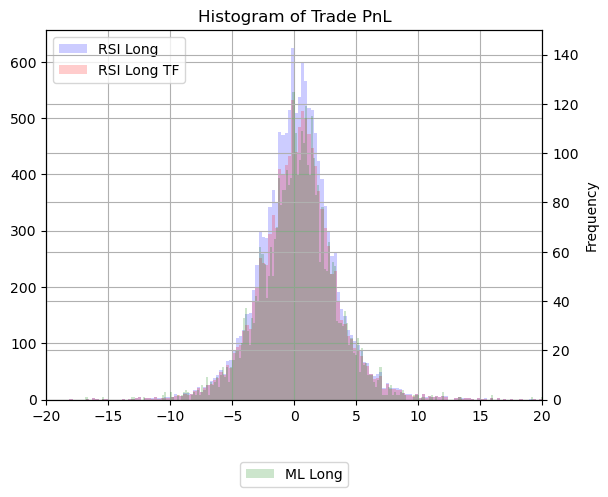

In [26]:
tradeslist_l = trading_rules_dict['rsi_l']._full_tradeslist()
tradeslist_l

tradeslist_l_tf = trading_rules_dict['rsi_l_tf']._full_tradeslist()
tradeslist_l_tf

tradeslist_ml_l = ml_long._full_tradeslist()
tradeslist_ml_l
ax = tradeslist_l['Std_PnL'].hist(bins=500, alpha=0.2, label='RSI Long', color='blue')
ax2 = ax.twinx()

tradeslist_l_tf['Std_PnL'].hist(bins=500, alpha=0.2, label='RSI Long TF', color='red', ax=ax)
tradeslist_ml_l['Std_PnL'].hist(bins=500, alpha=0.2, label='ML Long', ax=ax2, color='green')
ax2.set_ylim(0, 150)


ax.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=1)

plt.xlabel('Trade PnL')
plt.ylabel('Frequency')
plt.xlim(-20, 20)
plt.title('Histogram of Trade PnL')
plt.show()

In [27]:
from matplotlib.ticker import FuncFormatter
from matplotlib.colors import to_rgba
from scipy.stats import skewnorm, t, norm
from scipy.optimize import minimize
from scipy.special import gamma
import numpy as np
import matplotlib.pyplot as plt

def ged_pdf(x, loc, scale, p):
    # Generalized Error Distribution PDF
    c = p / (2 * scale * gamma(1 / p))
    return c * np.exp(-np.abs((x - loc) / scale) ** p)

def fit_and_plot_dist(data, label, color, dist='skewnorm'):
    num_trades = len(data)
    if dist == 'skewnorm':
        # Fit a skew-normal distribution to the data
        shape, loc, scale = skewnorm.fit(data)
        
        # Generate the fitted line
        x = np.linspace(min(data), max(data), 500)
        pdf_values = skewnorm.pdf(x, shape, loc, scale)
        peak = x[np.argmax(pdf_values)]  # True peak value
        
        # Plot the fitted line
        plt.plot(x, pdf_values, label=f'{label} (num_trades= {num_trades:,.0f}, dist_peak={peak:,.0f}, shape={shape:.2f}, loc={loc:,.2f}, scale={scale:,.2f})', color=color)
    
    elif dist == 'ged':
        # Define negative log-likelihood for GED
        def neg_log_likelihood(params):
            loc, scale, p = params
            if scale <= 0 or p <= 0:  # Constraints
                return np.inf
            return -np.sum(np.log(ged_pdf(data, loc, scale, p)))

        # Initial guesses for parameters
        initial_params = [np.mean(data), np.std(data), 1.5]
        bounds = [(None, None), (1e-5, None), (1e-5, None)]  # Enforce positive scale and p

        # Fit the parameters by minimizing the negative log-likelihood
        result = minimize(neg_log_likelihood, initial_params, bounds=bounds)
        loc, scale, p = result.x
        
        # Generate the fitted line
        x = np.linspace(min(data), max(data), 500)
        pdf_values = ged_pdf(x, loc, scale, p)
        peak = x[np.argmax(pdf_values)]  # True peak value
        
        # Plot the fitted line
        plt.plot(x, pdf_values, label=f'{label} (num_trades= {num_trades:,.0f}, dist_peak={peak:,.0f}, loc={loc:,.2f}, scale={scale:,.2f}, p={p:.2f})', color=color)

    elif dist == 't':
        # Fit a t-distribution to the data
        df, loc, scale = t.fit(data)
        
        # Generate the fitted line
        x = np.linspace(min(data), max(data), 500)
        pdf_values = t.pdf(x, df, loc, scale)
        peak = x[np.argmax(pdf_values)]  # True peak value
        
        # Plot the fitted line
        plt.plot(x, pdf_values, label=f'{label} (num_trades= {num_trades:,.0f}, dist_peak={peak:,.0f}, df={df:.2f}, loc={loc:,.2f}, scale={scale:,.2f})', color=color)

    else:
        # Fit a normal distribution to the data
        mu, std = norm.fit(data)
        
        # Generate the fitted line
        x = np.linspace(min(data), max(data), 500)
        pdf_values = norm.pdf(x, mu, std)
        peak = x[np.argmax(pdf_values)]  # True peak value
        
        # Plot the fitted line
        plt.plot(x, pdf_values, label=f'{label} (num_trades= {num_trades:,.0f}, dist_peak={peak:,.0f}, μ={mu:,.2f}, σ={std:,.2f})', color=color)
    
    # Add a vertical line at the peak
    darker_color = to_rgba(color, alpha=1.0)  # Get the RGBA value of the color
    darker_color = tuple(c * 0.6 for c in darker_color[:3]) + (1.0,)  # Make it darker
    plt.axvline(x=peak, color=darker_color, linestyle='--', linewidth=1)


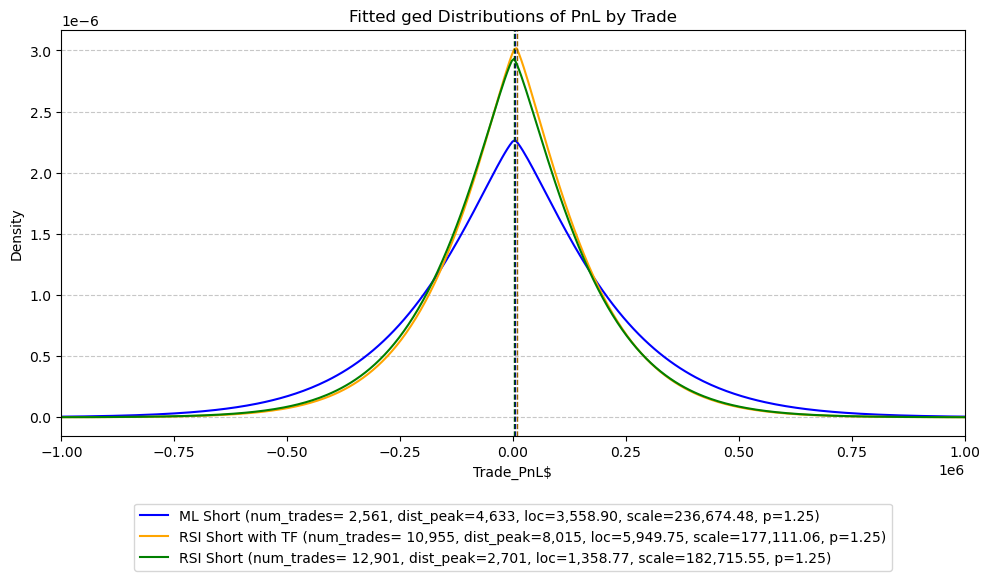

In [28]:
type_trade = 'Trade_PnL'
model_dist = 'ged'
ml_short_tl = tradeslist_ml_s[type_trade]
rsi_short_tf_tl = tradeslist_s_tf[type_trade]
rsi_short_tl = tradeslist_s[type_trade]


# Plot the fitted lines
plt.figure(figsize=(10, 6))
fit_and_plot_dist(ml_short_tl, 'ML Short', 'blue', dist=model_dist)
fit_and_plot_dist(rsi_short_tf_tl, 'RSI Short with TF', 'orange', dist=model_dist)
fit_and_plot_dist(rsi_short_tl, 'RSI Short', 'green', dist=model_dist)

plt.title(f'Fitted {model_dist} Distributions of PnL by Trade')
plt.xlabel(type_trade+'$')
plt.ylabel('Density')
plt.xlim(-1000000,1000000)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
# Add titles and labels


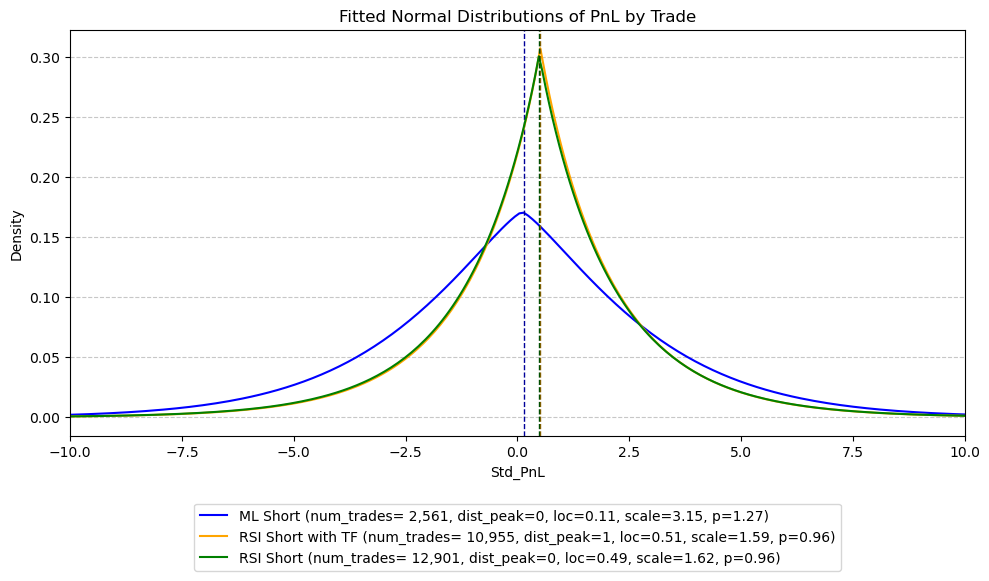

In [29]:
type_trade = 'Std_PnL'
model_dist = 'ged'
ml_short_tl = tradeslist_ml_s[type_trade]
rsi_short_tf_tl = tradeslist_s_tf[type_trade]
rsi_short_tl = tradeslist_s[type_trade]


# Plot the fitted lines
plt.figure(figsize=(10, 6))
fit_and_plot_dist(ml_short_tl, 'ML Short', 'blue', dist=model_dist)
fit_and_plot_dist(rsi_short_tf_tl, 'RSI Short with TF', 'orange', dist=model_dist)
fit_and_plot_dist(rsi_short_tl, 'RSI Short', 'green', dist=model_dist)

plt.title('Fitted Normal Distributions of PnL by Trade')
plt.xlabel(type_trade)
plt.ylabel('Density')
plt.xlim(-10,10)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
# Add titles and labels


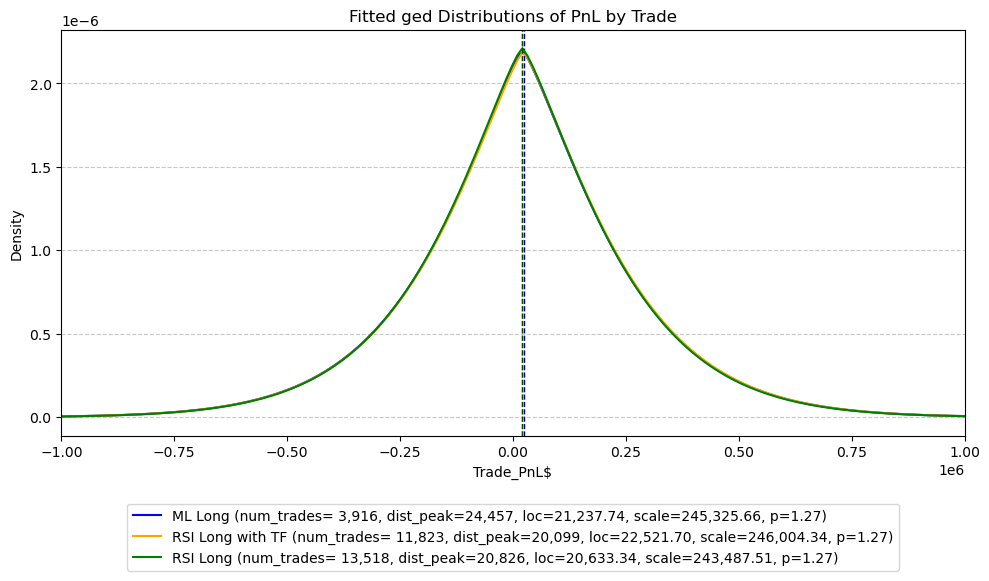

In [30]:
type_trade = 'Trade_PnL'
model_dist = 'ged'
ml_long_tl = tradeslist_ml_l[type_trade]
rsi_long_tf_tl = tradeslist_l_tf[type_trade]
rsi_long_tl = tradeslist_l[type_trade]


# Plot the fitted lines
plt.figure(figsize=(10, 6))
fit_and_plot_dist(ml_long_tl, 'ML Long', 'blue', dist=model_dist)
fit_and_plot_dist(rsi_long_tf_tl, 'RSI Long with TF', 'orange', dist=model_dist)
fit_and_plot_dist(rsi_long_tl, 'RSI Long', 'green', dist=model_dist)

plt.title(f'Fitted {model_dist} Distributions of PnL by Trade')
plt.xlabel(type_trade+'$')
plt.ylabel('Density')
plt.xlim(-1000000,1000000)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
# Add titles and labels


In [31]:
tradeslist_ml_s.sort_values('Std_PnL', ascending=False).tail(20).to_clipboard()

In [32]:
fxtrades = tradeslist_ml_s[tradeslist_ml_s['AssetClass']=='fx-dm']
fxtrades

,Descr,AssetClass,Asset,FirstDate,LastDate,TradeEntry,TradeExit,USD_Notional,Num_Lots,Trade_PnL,...,mlfeat_ewma_diff_short,mlfeat_ewma_diff_long,mlfeat_volume_zscore,mlfeat_adx,mlfeat_carry_change,mlfeat_carry_ema_diff,mlfeat_skew,mlfeat_result,mlfeat_probability,mlfeat_hist_count
Trade_ID,,,,,,,,,,,,,,,,,,,,,
f2ae_JY1Cur_1,JPN YEN CURR FUT,fx-dm,JY1 Curncy,1990-03-15,1990-03-23,137.8,137.5,"-30,430,400",-176.0,"90,075",...,-0.98,-3.69,1.84,35.1,7.59,15.1,-0.56,0.00,0.72,10.0
f2ae_AD1Cur_1,AUDUSD Crncy Fut,fx-dm,AD1 Curncy,1991-03-08,1991-03-18,36.3,36.3,"-8,189,025",-227.0,"-1,460",...,-2.21,0.42,-0.65,18.9,-2.47,-4.12,1.63,-0.00,1.00,5.00
f2ae_JY1Cur_2,JPN YEN CURR FUT,fx-dm,JY1 Curncy,1991-03-11,1991-03-19,145.0,144.8,"-21,080,100",-116.0,"7,738",...,-1.12,-0.97,0.28,64.2,4.30,14.1,-0.35,0.00,0.78,20.0
f2ae_SF1Cur_1,CHF CURRENCY FUT,fx-dm,SF1 Curncy,1991-06-07,1991-06-17,117.9,116.3,"-15,625,725",-106.0,"226,550",...,-1.13,-3.07,-1.95,18.8,-29.4,42.1,-0.08,0.01,0.83,11.0
f2ae_BP1Cur_1,BP CURRENCY FUT,fx-dm,BP1 Curncy,1991-06-07,1991-06-17,126.0,120.7,"-6,725,094",-85.0,"303,150",...,-0.77,-2.28,-2.03,35.5,2.99,6.69,0.18,0.04,0.83,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
f2ae_CD1Cur_40,C$ CURRENCY FUT,fx-dm,CD1 Curncy,2024-07-31,2024-08-08,72.5,73.1,"-40,376,930",-557.0,"-222,750",...,-0.88,-1.50,-0.59,30.0,-13.6,-11.8,0.48,-0.01,0.66,30.0
f2ae_BP1Cur_51,BP CURRENCY FUT,fx-dm,BP1 Curncy,2024-10-08,2024-10-16,130.8,129.8,"-15,603,506",-191.0,"136,706",...,-0.98,1.42,-0.92,25.0,3.84,5.36,0.38,0.01,0.87,29.0
f2ae_SE1Cur_32,SWEDISH KRONA FUT,fx-dm,SE1 Curncy,2024-10-08,2024-10-16,9.70,9.53,"-13,939,200",-72.0,"259,250",...,-0.82,0.82,-0.54,15.2,-1.62,-3.32,0.08,0.02,0.76,30.0


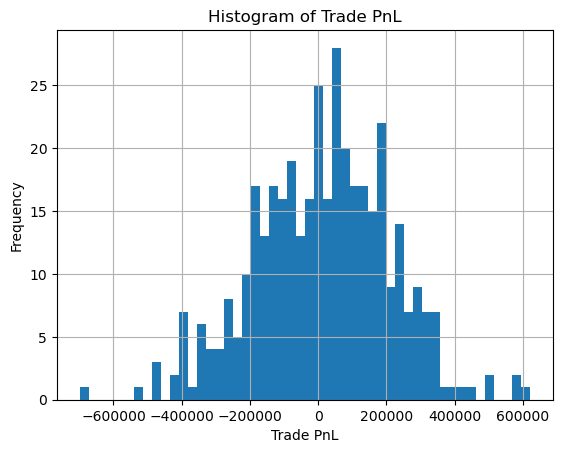

In [33]:
fxtrades['Trade_PnL'].hist(bins=50)
plt.xlabel('Trade PnL')
plt.ylabel('Frequency')
plt.title('Histogram of Trade PnL')
plt.show()

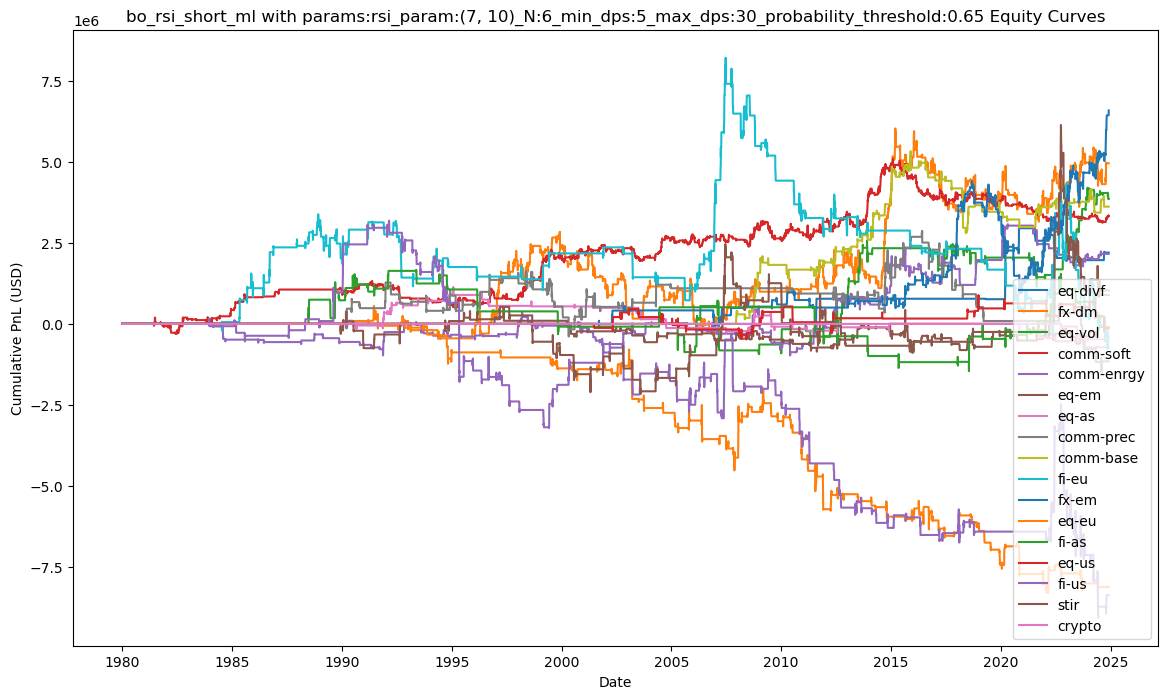

In [34]:
pnls = ml_short.plot_equity(byac=True, totalsys=False)

In [35]:
pnls

,eq-divf,fx-dm,eq-vol,comm-soft,comm-enrgy,eq-em,eq-as,comm-prec,comm-base,fi-eu,fx-em,eq-eu,fi-as,eq-us,fi-us,stir,crypto,Total
Date,,,,,,,,,,,,,,,,,,
1980-01-02,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1980-01-03,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1980-01-04,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1980-01-07,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1980-01-08,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-11-25,"2,200,312","4,954,270","3,851,853","3,322,260","2,161,005","-103,948","-720,505","-1,155,230","3,616,820","-429,190","6,435,181","-8,114,925","892,017","-142,360","-8,368,991","1,035,160","-472,450","8,961,280"
2024-11-26,"2,200,312","4,954,270","3,851,853","3,322,260","2,161,005","-103,948","-720,505","-1,155,230","3,616,820","-429,190","6,435,181","-8,114,925","892,017","-142,360","-8,368,991","1,035,160","-472,450","8,961,280"
2024-11-27,"2,200,312","4,954,270","3,851,853","3,322,260","2,161,005","-103,948","-720,505","-1,155,230","3,616,820","-429,190","6,435,181","-8,114,925","892,017","-142,360","-8,368,991","1,035,160","-472,450","8,961,280"


In [36]:
allpnls = pnls.iloc[-1].sort_values(ascending=False)

In [37]:
allpnls.to_clipboard()

<Axes: >

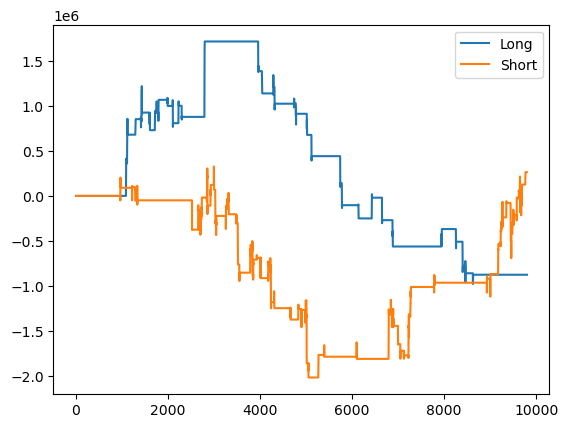

In [38]:
gcbt_s = ml_short._get_btdf('JY1 Curncy')
gcbt_l = ml_long._get_btdf('JY1 Curncy')
gcshort = gcbt_s['Strategy_Equity_USD']
gclong = gcbt_l['Strategy_Equity_USD']

gclongshort = pd.DataFrame({'Long':gclong,'Short':gcshort})
gclongshort.plot()

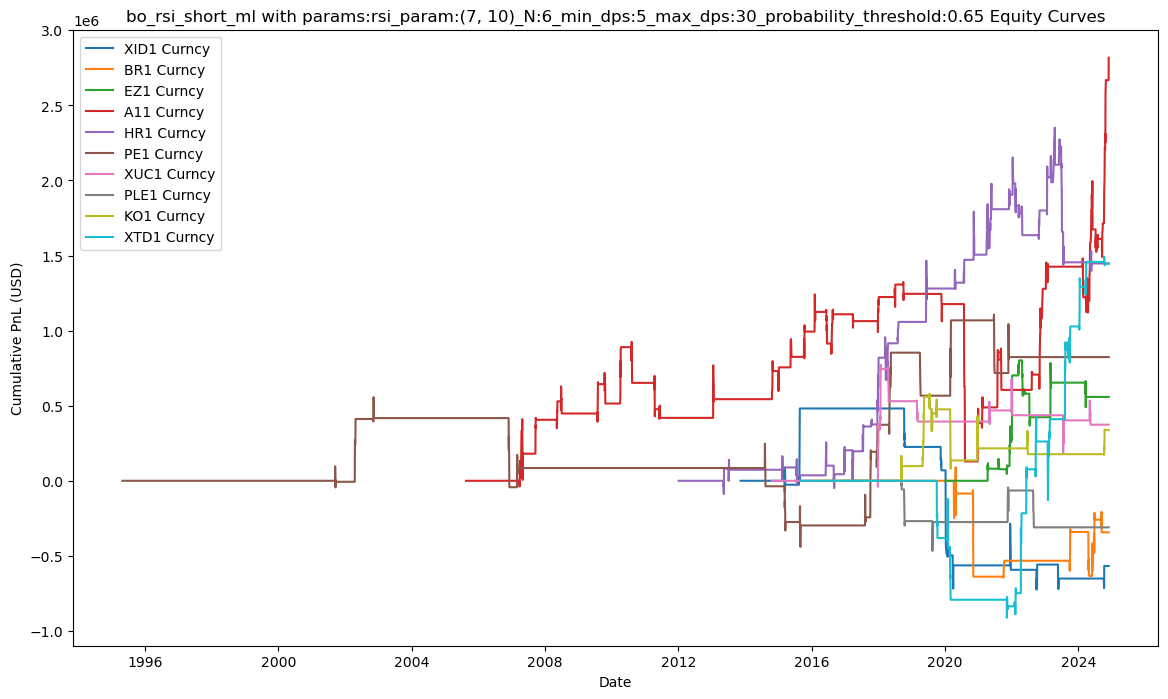

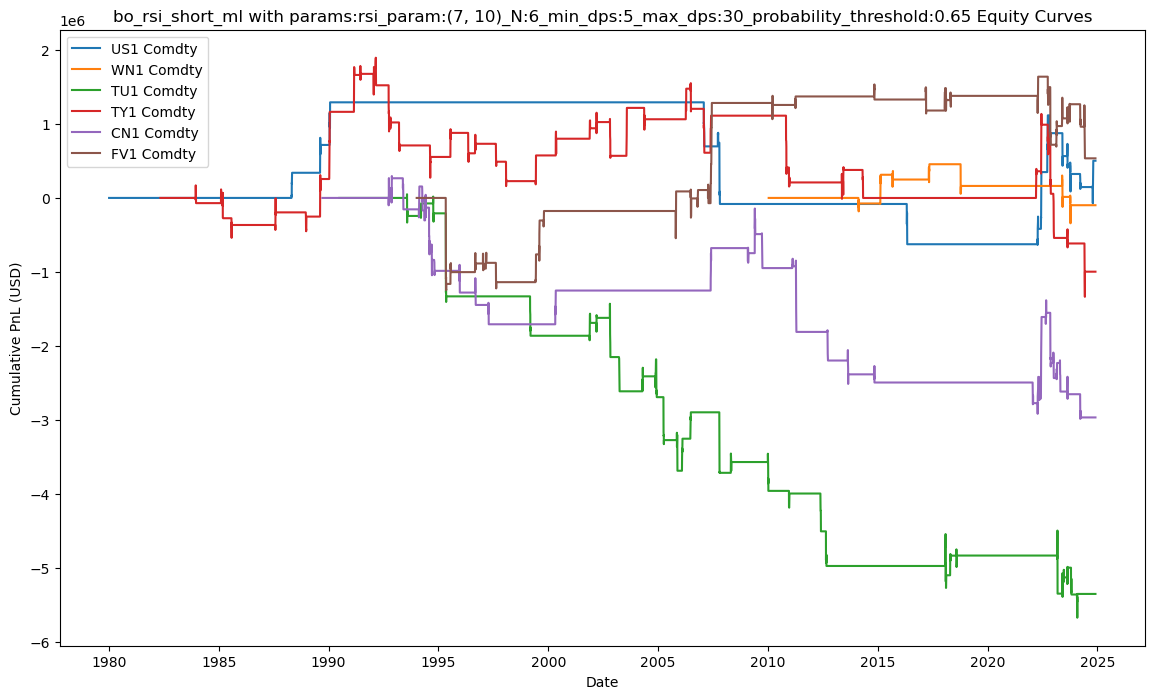

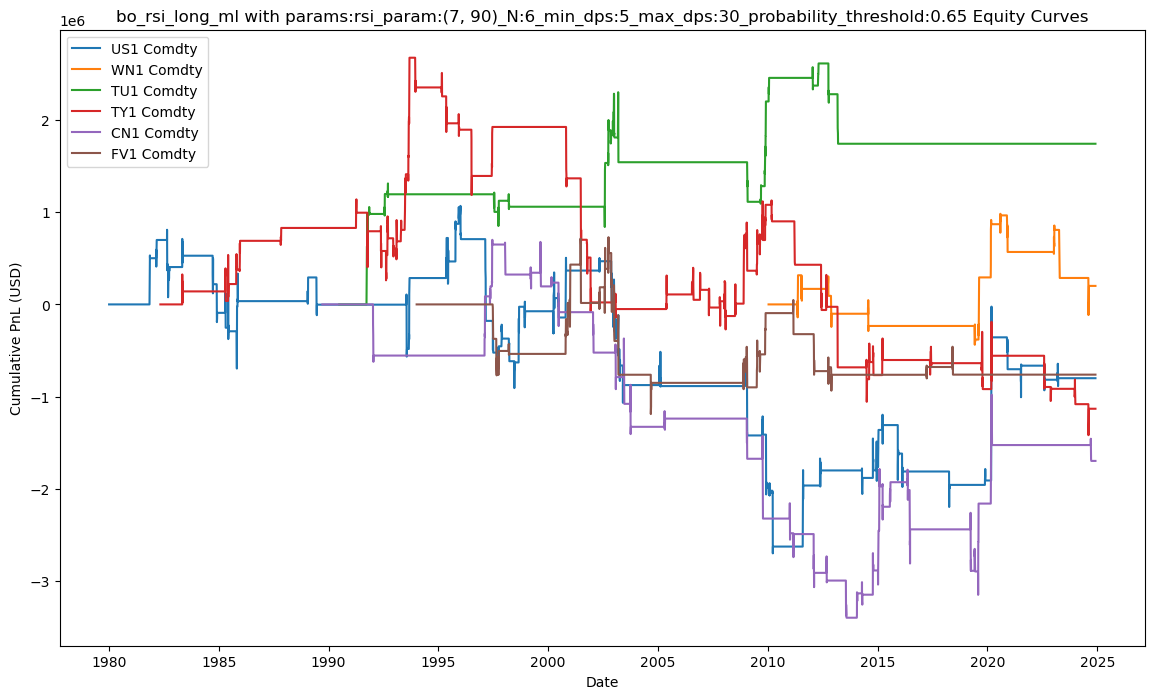

,US1 Comdty,WN1 Comdty,TU1 Comdty,TY1 Comdty,CN1 Comdty,FV1 Comdty,Total
Date,,,,,,,
1980-01-02,NaN,NaN,NaN,NaN,NaN,NaN,0.00
1980-01-03,0.00,NaN,NaN,NaN,NaN,NaN,0.00
1980-01-04,0.00,NaN,NaN,NaN,NaN,NaN,0.00
1980-01-07,0.00,NaN,NaN,NaN,NaN,NaN,0.00
1980-01-08,0.00,NaN,NaN,NaN,NaN,NaN,0.00
...,...,...,...,...,...,...,...
2024-11-26,"-799,969","200,562","1,741,547","-1,131,094","-1,696,592","-761,328","-2,446,874"
2024-11-27,"-799,969","200,562","1,741,547","-1,131,094","-1,696,592","-761,328","-2,446,874"
2024-11-28,"-799,969","200,562","1,741,547","-1,131,094","-1,696,592","-761,328","-2,446,874"


In [39]:
ml_short.plot_equity(byassets=True, totalsys=False,filter_assets=asset_classes['fx-em'])
ml_short.plot_equity(byassets=True, totalsys=False,filter_assets=asset_classes['fi-us'])
ml_long.plot_equity(byassets=True, totalsys=False,filter_assets=asset_classes['fi-us'])

<Axes: xlabel='Date'>

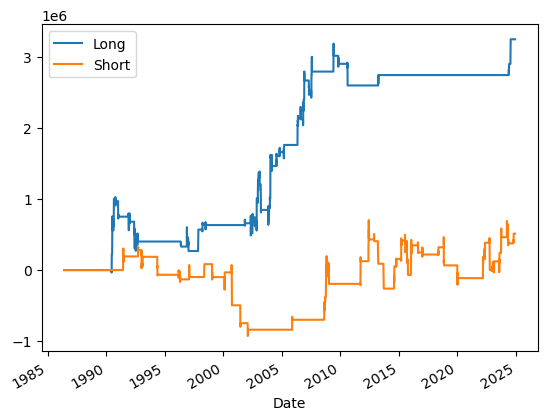

In [40]:
tck = 'BP1 Curncy'
tck_short_ml = ml_short.backtest_asset(tck,save=True)
tck_long_ml = ml_long.backtest_asset(tck,save=True)
tck_short_ml.set_index('Date', inplace=True)
tck_long_ml.set_index('Date', inplace=True)
tck_longshort = pd.DataFrame({'Long':tck_long_ml['Strategy_Equity_USD'],'Short':tck_short_ml['Strategy_Equity_USD']})
tck_longshort.plot()

In [41]:
tck_short_ml.to_clipboard()

In [42]:
tradeslist_s = ml_short._full_tradeslist()
tradeslist_l = ml_long._full_tradeslist()

tradeslist_s_tck = tradeslist_s[tradeslist_s['Asset'] == tck]
tradeslist_s_tck.to_clipboard()

In [43]:
tl_list = []

for tck in tradeslist_l_tf['Asset'].unique():
    ml_t = ml_long._get_btdf(tck)
    ml_t.reset_index(inplace=True)
    ml_feats = ml_t[['Date'] + [x for x in ml_t.columns if x[:7] == 'mlfeat_']].dropna()
    ml_feats['Asset'] = tck
    tl_list.append(ml_feats)

all_ml_feats = pd.concat(tl_list)


all_ml_feats = tradeslist_ml_l

try:
    all_ml_feats.sort_values('Date', inplace=True)
except:
    all_ml_feats.sort_values('FirstDate', inplace=True)
print(len(all_ml_feats))
all_ml_feats = all_ml_feats[np.abs(all_ml_feats['mlfeat_result'])<15]

3916


In [44]:
all_ml_feats

,Descr,AssetClass,Asset,FirstDate,LastDate,TradeEntry,TradeExit,USD_Notional,Num_Lots,Trade_PnL,...,mlfeat_ewma_diff_short,mlfeat_ewma_diff_long,mlfeat_volume_zscore,mlfeat_adx,mlfeat_carry_change,mlfeat_carry_ema_diff,mlfeat_skew,mlfeat_result,mlfeat_probability,mlfeat_hist_count
Trade_ID,,,,,,,,,,,,,,,,,,,,,
6cb2_BO1Com_1,SOYBEAN OIL FUTR,comm-soft,BO1 Comdty,1980-07-21,1980-07-29,59.4,58.9,"3,670,164",102.0,"-30,282",...,1.10,2.65,-1.68,26.8,-6.03,-3.35,-0.37,-0.01,1.00,5.00
6cb2_SM1Com_1,SOYBEAN MEAL FUTR,comm-soft,SM1 Comdty,1980-08-27,1980-09-05,-402.1,-389.5,"-2,492,400",62.0,"79,520",...,0.99,2.64,0.42,25.4,5.46,3.13,0.19,-0.03,1.00,5.00
6cb2_S1Comd_1,SOYBEAN FUTURE,comm-soft,S 1 Comdty,1980-09-04,1980-09-12,376.8,374.3,"659,422",35.0,"-8,012",...,1.40,2.23,1.24,16.5,-17.1,-10.2,-0.24,-0.01,1.00,5.00
6cb2_SM1Com_2,SOYBEAN MEAL FUTR,comm-soft,SM1 Comdty,1980-09-24,1980-10-02,-372.1,-393.3,"-2,637,650",71.0,"-140,240",...,1.12,4.34,1.94,12.8,0.33,-0.07,0.19,0.06,1.00,6.00
6cb2_S1Comd_2,SOYBEAN FUTURE,comm-soft,S 1 Comdty,1980-12-23,1981-01-05,314.1,320.1,"449,591",29.0,"10,312",...,0.15,-1.73,-0.14,44.2,-4.41,-21.6,0.01,0.02,0.93,8.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6cb2_BTC1Cu_16,CME Bitcoin Fut,crypto,BTC1 Curncy,2024-11-13,2024-11-21,"90,080","99,700","1,817,000",4.00,"192,400",...,2.14,1.88,1.72,15.6,-19.9,-11.5,0.01,0.11,0.94,30.0
6cb2_NQ1Ind_79,NASDAQ 100 E-MINI,eq-us,NQ1 Index,2024-11-13,2024-11-21,"21,178","20,830","8,899,590",21.0,"-158,565",...,0.86,1.65,0.09,18.7,-29.1,-32.3,0.47,-0.02,0.66,30.0
6cb2_QC1Com_40,COCOA FUTURE - IC,comm-soft,QC1 Comdty,2024-11-18,2024-11-26,"6,928","7,602","867,740",10.0,"89,821",...,2.01,1.29,-1.19,15.2,-25.2,-25.2,0.91,0.10,0.70,30.0


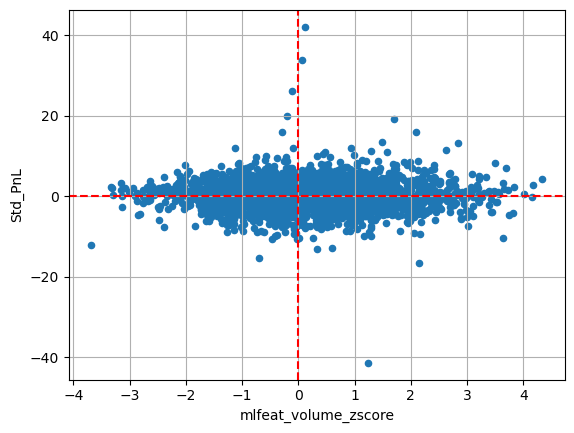

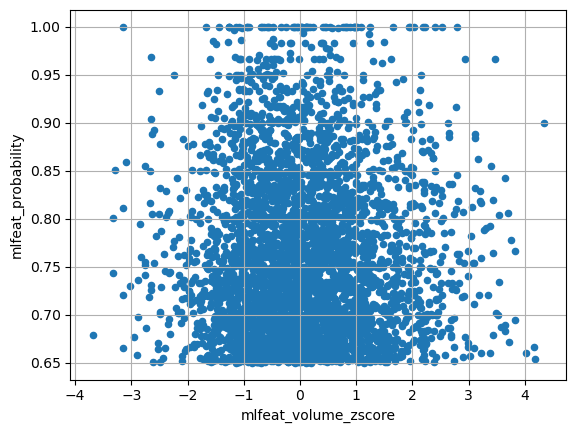

In [45]:
ax = all_ml_feats.plot(kind='scatter', x='mlfeat_volume_zscore', y='Std_PnL', grid=True)
all_ml_feats.plot(kind='scatter', x='mlfeat_volume_zscore', y='mlfeat_probability', grid=True)
# Add horizontal and vertical lines through the axis
ax.axhline(y=0, color='r', linestyle='--')
ax.axvline(x=0, color='r', linestyle='--')

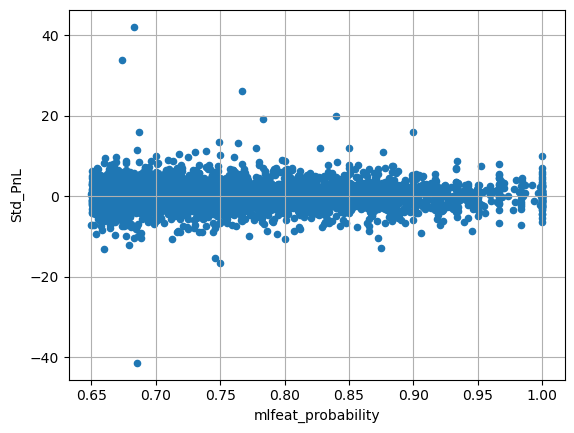

In [46]:
ax = all_ml_feats.plot(kind='scatter', x='mlfeat_probability', y='Std_PnL', grid=True)


/var/folders/m4/1ljrqkl53mx809bbs_bwc0jr0000gn/T/ipykernel_20684/2302767626.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['probability_bucket'] = pd.cut(df['mlfeat_probability'], bins=np.arange(0, 1.1, 0.1), labels=bucket_labels, include_lowest=True)
/var/folders/m4/1ljrqkl53mx809bbs_bwc0jr0000gn/T/ipykernel_20684/2302767626.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_metrics = df.groupby('probability_bucket').apply(calculate_metrics)
/var/folders/m4/1ljrqkl53mx809bbs_bwc0jr0000gn/T/ipykernel_20684/2302767626.py:18: DeprecationWarnin

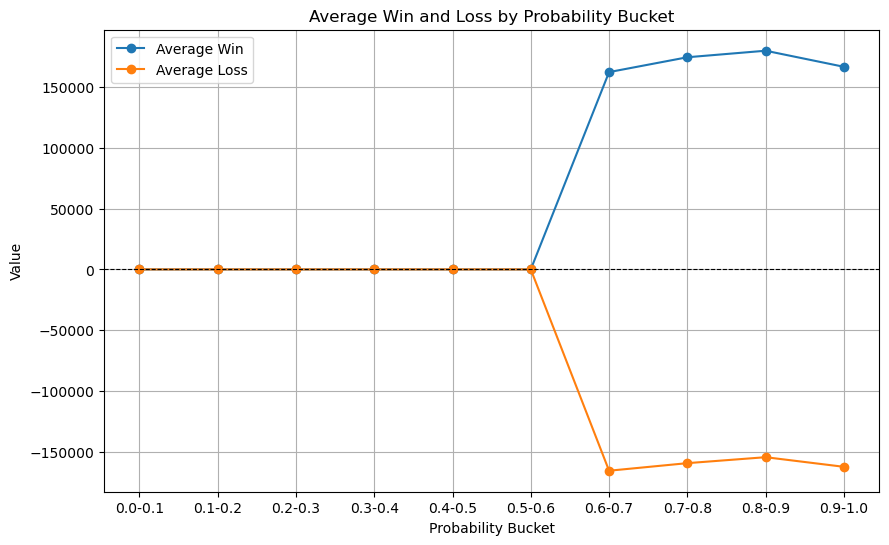

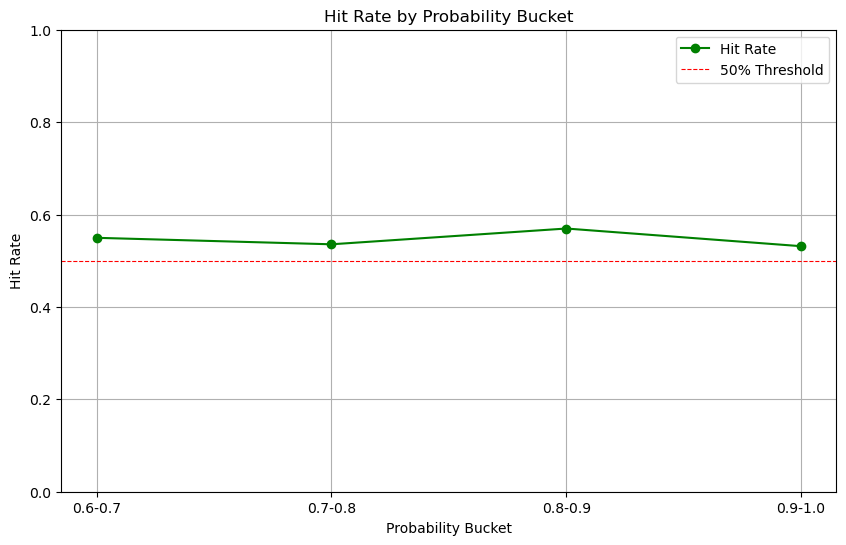

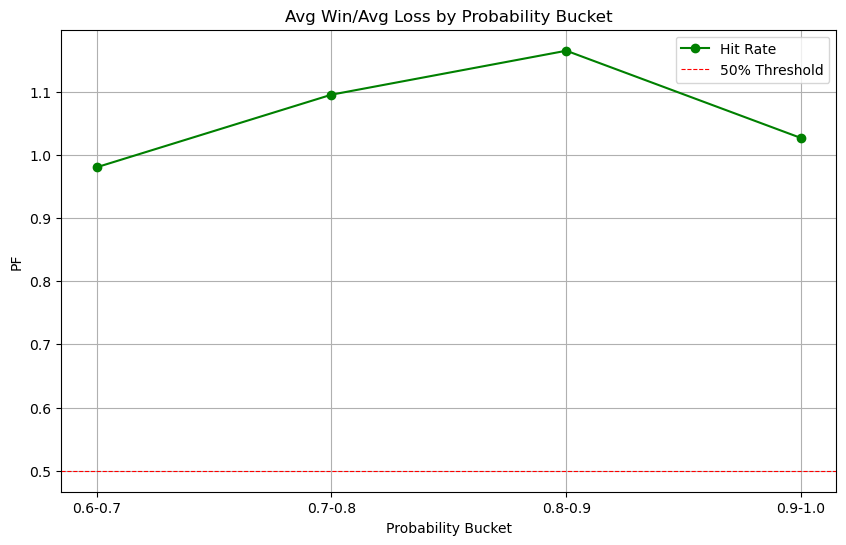

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Assuming your DataFrame is named `df` with columns 'mlfeat_probability' and metric_col
df =all_ml_feats
# Step 1: Create probability buckets
bucket_labels = [f"{i/10}-{(i+1)/10}" for i in range(10)]
df['probability_bucket'] = pd.cut(df['mlfeat_probability'], bins=np.arange(0, 1.1, 0.1), labels=bucket_labels, include_lowest=True)

# Step 2: Calculate metrics for each bucket
def calculate_metrics(group, metric_col='Trade_PnL'):
    avg_win = group[group[metric_col] > 0][metric_col].mean() if not group[group[metric_col] > 0].empty else 0
    avg_loss = group[group[metric_col] < 0][metric_col].mean() if not group[group[metric_col] < 0].empty else 0
    hit_rate = (group[metric_col] > 0).mean()
    return pd.Series({'avg_win': avg_win, 'avg_loss': avg_loss, 'hit_rate': hit_rate})

bucket_metrics = df.groupby('probability_bucket').apply(calculate_metrics)

# Step 3: Visualization
# Plot average win and average loss
plt.figure(figsize=(10, 6))
plt.plot(bucket_metrics.index, bucket_metrics['avg_win'], label='Average Win', marker='o')
plt.plot(bucket_metrics.index, bucket_metrics['avg_loss'], label='Average Loss', marker='o')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Average Win and Loss by Probability Bucket')
plt.xlabel('Probability Bucket')
plt.ylabel('Value')
plt.legend()
plt.grid()
plt.show()

# Plot hit rate
plt.figure(figsize=(10, 6))
plt.plot(bucket_metrics.index, bucket_metrics['hit_rate'], label='Hit Rate', marker='o', color='green')
plt.title('Hit Rate by Probability Bucket')
plt.xlabel('Probability Bucket')
plt.ylabel('Hit Rate')
plt.ylim(0, 1)
plt.axhline(0.5, color='red', linewidth=0.8, linestyle='--', label='50% Threshold')
plt.legend()
plt.grid()
plt.show()


plt.figure(figsize=(10, 6))
plt.plot(bucket_metrics.index, np.abs(bucket_metrics['avg_win']/bucket_metrics['avg_loss']), label='Hit Rate', marker='o', color='green')
plt.title('Avg Win/Avg Loss by Probability Bucket')
plt.xlabel('Probability Bucket')
plt.ylabel('PF')
plt.axhline(0.5, color='red', linewidth=0.8, linestyle='--', label='50% Threshold')
plt.legend()
plt.grid()
plt.show()